In [6]:
import xarray as xr
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon
from scipy.stats import pearsonr
import geopandas as gpd
import sys
from mpl_toolkits.basemap import Basemap
import pyproj
from pyproj import Proj, transform
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FuncFormatter

from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm

import scipy.stats as st 

In [9]:
# Define the source and target CRS
src_crs = Proj('EPSG:4326')
target_crs = Proj(proj='latlong', datum='WGS84')

# Now, use lon_values_reprojected and lat_values_reprojected in your plt.imshow() and shapefile plotting functions

# Load the shapefile using geopandas
shapefile_path = "/home/renatob/data/FluoData1/aviris_dangermond/dangermond_bound/dan_bound2.shp"
gdf = gpd.read_file(shapefile_path)


# Plot LMA trait maps

In [10]:
# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Base file path
#base_file_path = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/fitting/shift_fluxes_day_{}_reg_jmax.nc"
base_file_path1 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"
base_file_path11 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/chl_aviris_dangermond_clima_fit_time_{}_reg.nc"

# Open the NetCDF file for TROPOMI dataset
#file2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/TROPOMI_dangermond/TROPOMI_SIF740nm-v1.001deg_regrid_Dangermond_tll_clipped_458_492.nc"
base_file_path2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/masked_lwc_aviris_dangermond_time_{}.nc"


#ds2 = xr.open_dataset(file2, decode_times=True)

# Save dates, mean, and std values to a text file
try:
    file = open('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_statistics_hr_clima_fit_.txt', 'w')
    file.write('Date\tMean Observed\tStd Observed\tCI95 Observed\tMean Predicted\tStd Predicted\tCI95 Predicted\n')
except Exception as e:
    print(f"Error: {e}")


# Initialize empty lists to accumulate data points
observed_all = []
predicted_all = []

# Initialize a list to store individual spatial differences
spatial_diff_list = []

for i, target_date_str in enumerate(dates):
    # Construct file1 dynamically based on the time step index (i)
    file1 = base_file_path1.format(str(i).zfill(2))
    file11 = base_file_path11.format(str(i).zfill(2))

    file2 = base_file_path2.format(str(i).zfill(2))


    # Open dataset for file1
    ds1 = xr.open_dataset(file1, decode_times=False)  
    ds11 = xr.open_dataset(file11, decode_times=False)  

    ds2 = xr.open_dataset(file2, decode_times=False)  

    
    target_date = pd.Timestamp(target_date_str).value / 10**9  # Convert to seconds since epoch
    print('target_date=',target_date)
    # Convert target_date to datetime64[ns]cat c
    target_date = pd.to_datetime(target_date, unit='s')
    print('target_date=',target_date)



    # Calculate the average time of the selected data in ds2_selected

    ds1_selected = ds1['lwc']*(ds11['chl']/ds11['chl'])
    ds2_selected = ds2['lwc']

      
    # Filter out NaN values
    valid_indices = ~np.isnan(ds2_selected.values.flatten()) & ~np.isnan(ds1_selected.values.flatten())
    if valid_indices.any():
        pft = ds2_selected.values.flatten()[valid_indices]
        trait = ds1_selected.values.flatten()[valid_indices]
        
        print("Observed shape before cleaning:", pft.shape)
        print("Predicted shape before cleaning:", trait.shape)

        pft = pft[~np.isnan(pft)]
        trait = trait[~np.isnan(trait)]

        print("Observed shape after cleaning:", pft.shape)
        print("Predicted shape after cleaning:", trait.shape)


        print('mean obs =', np.mean(pft))
        print('mean pred =', np.mean(trait))

        # Calculate spatial differences
        spatial_diff_num =  trait 

        # Squeeze the array to remove the singleton dimension
        spatial_diff_num = np.squeeze(spatial_diff_num)   
        
        # Calculate spatial differences
        spatial_diff =  ds1_selected.values
        
        # Squeeze the array to remove the singleton dimension
        spatial_diff = np.squeeze(spatial_diff)
        
        
        # Calculate spatial differences and append them to the list
        spatial_diff_list.append(spatial_diff)

        #Get latitude and longitude values
        lat_values = ds2_selected['lat'].values
        lon_values = ds2_selected['lon'].values
        
        # Calculate metrics
        mae = mean_absolute_error(pft, trait)

        # Calculate mean, std, bias, RMSE, and R²
        mean_pft = np.mean(pft)
        mean_trait = np.mean(trait)
        std_pft = np.std(pft)
        std_trait = np.std(trait)
        bias = mean_trait - mean_pft
        rmse = np.sqrt(np.mean((trait - pft)**2))
        slope, intercept, r_value, p_value, std_err = linregress(pft, trait)
        r2 = r_value**2


        
        #plt.imshow(spatial_diff)
        #plt.colorbar()
        #plt.show()
        #plt.close()
        print("mae:", mae)
        print("bias:", bias)
        print("RMSE:", rmse)
        print("R^2 Score:", r2)

        # create 95% confidence interval 
        ci95_observed = st.t.interval(0.95, df=len(pft)-1, 
                        loc=np.mean(pft), 
                        scale=st.sem(pft)) 

        # create 95% confidence interval 
        ci95_predicted = st.t.interval(0.95, df=len(trait)-1, 
                        loc=np.mean(trait), 
                        scale=st.sem(trait)) 
  
        # Append statistics for the current date to the file
        file.write(f'{target_date_str}\t{mean_pft}\t{std_pft}\t{ci95_observed}\t{mean_trait}\t{std_trait}\t{ci95_predicted}\t{bias}\t{rmse}\t{r2}\n')

        # Create a Basemap instance with the desired projection
        m = Basemap(projection='merc', llcrnrlat=lat_values.min(), urcrnrlat=lat_values.max(),
                llcrnrlon=lon_values.min(), urcrnrlon=lon_values.max(), resolution='c')

        x,y = np.meshgrid(lon_values, lat_values) 
        X,Y = m(x, y)
        
        # Define the number of decimal places for meridian and parallel labels
        decimal_places = 3

        # Define a custom formatter function to format the labels with the specified number of decimal places
        def format_labels(x, pos):
            return '{:.{decimal_places}f}'.format(x, decimal_places=decimal_places)


        # Create a figure and axes
        plt.figure(figsize=(8, 6))
        m.drawparallels(np.arange(-90.,91.,0.025), labels=[1,0,0,1],    dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        m.drawmeridians(np.arange(0., 360., 0.025), labels=[1,0,0,1], dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        #m.drawcoastlines(color='0.6', linewidth=0.5)

        # Plot spatial differences using pcolormesh with Basemap
        cs = m.pcolormesh(X, Y, spatial_diff, cmap='YlGn', vmin=0, vmax=10)

        vmin = 0.
        vmax = 10.
        cbar = m.colorbar(cs, pad='10%',ticks=np.linspace(vmin,vmax,5),format='%.2f')
        cbar.ax.get_yaxis().labelpad = 10
        cbar.ax.set_ylabel(r'LWC (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
        cbar.solids.set_edgecolor("face")
        #cbar.set_clim(vmin,vmax)
        # Assuming cbar is your Colorbar object
        #cbar.ax.set_clim(vmin, vmax)
        cbar.ax.tick_params(labelsize='large')
        #gdf.plot(ax=m, linewidth=1, edgecolor='black', facecolor='none', legend=True)
        #m.readshapefile(shapefile_path,'Geometry')
        # Plot contour of Dangermond shapefile
        #m.readshapefile(shapefile_path, 'dan_bound2', linewidth=2, color='black')
        
        # Manually draw shapefile polygons on top of the contour plot
        for shape in gdf['geometry']:
            if shape.geom_type == 'Polygon':
                x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
                polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
                plt.gca().add_patch(polygon)

        # Plot spatial differences with latitude and longitude values on the y and x axes
        #plt.imshow(spatial_diff, cmap='coolwarm', vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data range
    
        # Overlay shapefile contour on top of the spatial differences plot
        #gdf.plot(ax=plt.gca(), linewidth=1, edgecolor='black', facecolor='none', legend=True)


        # Set title, labels, and tick formatters
        plt.title(f'Date {target_date_str}',fontsize=14)
        #plt.xlabel('Longitude')
        #plt.ylabel('Latitude')
    

        # Add colorbar to the right of the plot
        #divider = make_axes_locatable(ax)
        #cax = divider.append_axes("right", size="5%", pad=0.1)


        
        # Set 2 decimal places for latitude and longitude ticks
        #lat_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lat_values[x]))
        #lon_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lon_values[x]))
        
        
        # Get latitude and longitude values from your SIF data
        #lat_min, lat_max = lat_values.min(), lat_values.max()
        #lon_min, lon_max = lon_values.min(), lon_values.max()
        #print( lon_min, lon_max,lat_min, lat_max)
        
        # Set 4 ticks for latitude and longitude
        #num_ticks = 4
        #lat_indices = np.linspace(0, len(lat_values) - 1, num_ticks, dtype=int)
        #lon_indices = np.linspace(0, len(lon_values) - 1, num_ticks, dtype=int)

        # Set x and y ticks with actual lat and lon values formatted to 2 decimal places
        #plt.xticks(lon_indices, lon_values[lon_indices])
        #plt.yticks(lat_indices, lat_values[lat_indices])

        # Set formatted latitude and longitude tick labels
        #plt.gca().get_xaxis().set_major_formatter(lon_formatter)
        #plt.gca().get_yaxis().set_major_formatter(lat_formatter)
        


        # Add text box with statistics in the upper right corner
        bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
        plt.gca().text(0.95, 0.95, f'Mean: {mean_trait:.2f}\nSTD: {std_trait:.2f}',
                transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right',fontsize=14)
                


        # Invert the latitude axis
        #plt.gca().invert_yaxis()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_{i:02d}_trait_map_clima_fit.png',dpi=300)
        #plt.show()
        #sys.exit()
        
        # Close the figure to avoid displaying multiple plots at once
        plt.close()
        print('Figure spatial_differences_{i}.png saved!')
        

        # Filter out NaN values
        valid_indices = ~np.isnan(ds1_selected.values) & ~np.isnan(ds2_selected.values)
        pft = ds2_selected.values.reshape(-1)[valid_indices.reshape(-1)]
        trait = ds1_selected.values.reshape(-1)[valid_indices.reshape(-1)]

        # Check if there are still valid values after filtering
        if len(pft) > 0 and len(trait) > 0:
            # Accumulate observed and predicted values
            observed_all.extend(pft)
            predicted_all.extend(trait)

        # Close the datasets to free up resources
        ds1.close()
        ds2_selected.close()
        
        print('Total matrix ammended!')
        print(spatial_diff_list)
    
    
# Calculate the average spatial difference after the loop
average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)  

mean_trait = np.nanmean(average_spatial_diff) 
std_trait = np.nanstd(average_spatial_diff) 

# Create a figure and axes
plt.figure(figsize=(8, 6))
m.drawparallels(np.arange(-90., 91., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)
m.drawmeridians(np.arange(0., 360., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)

# Plot spatial differences using pcolormesh with Basemap
cs = m.pcolormesh(X, Y, average_spatial_diff, cmap='YlGn', vmin=0, vmax=10.)

vmin = 0
vmax = 10.
cbar = m.colorbar(cs, pad='10%', ticks=np.linspace(vmin, vmax, 5), format='%.2f')
cbar.ax.get_yaxis().labelpad = 10
cbar.ax.set_ylabel(r'LWC (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
cbar.solids.set_edgecolor("face")
cbar.ax.tick_params(labelsize='large')

# Manually draw shapefile polygons on top of the contour plot
for shape in gdf['geometry']:
    if shape.geom_type == 'Polygon':
       x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
       polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
       plt.gca().add_patch(polygon)

# Set title, labels, and tick formatters
plt.title(f'Mean', fontsize=14)

# Add text box with statistics in the upper right corner
bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
plt.gca().text(0.95, 0.95, f'Mean: {mean_trait:.2f}\nSTD: {std_trait:.2f}',
           transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right', fontsize=14)


plt.tight_layout()
# Save the figure
plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_mean_trait_clima_fit.png', dpi=300)


# Close the figure to avoid displaying multiple plots at once
plt.close()
print(f'Figure pft_spatial_differences_{i}.png saved!')


Error: [Errno 2] No such file or directory: '/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_statistics_hr_clima_fit_.txt'


FileNotFoundError: [Errno 2] No such file or directory: '/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_00_reg.nc'

### LMA PFT

In [ ]:
# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Base file path
#base_file_path = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/fitting/shift_fluxes_day_{}_reg_jmax.nc"
base_file_path1 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"
base_file_path11 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/chl_aviris_dangermond_clima_fit_time_{}_reg.nc"

# Open the NetCDF file for TROPOMI dataset
#file2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/TROPOMI_dangermond/TROPOMI_SIF740nm-v1.001deg_regrid_Dangermond_tll_clipped_458_492.nc"
base_file_path2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/masked_lwc_aviris_dangermond_time_{}.nc"


#ds2 = xr.open_dataset(file2, decode_times=True)

# Save dates, mean, and std values to a text file
try:
    file = open('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_statistics_hr.txt', 'w')
    file.write('Date\tMean Observed\tStd Observed\tCI95 Observed\tMean Predicted\tStd Predicted\tCI95 Predicted\n')
except Exception as e:
    print(f"Error: {e}")


# Initialize empty lists to accumulate data points
observed_all = []
predicted_all = []

# Initialize a list to store individual spatial differences
spatial_diff_list = []

for i, target_date_str in enumerate(dates):
    # Construct file1 dynamically based on the time step index (i)
    file1 = base_file_path1.format(str(i).zfill(2))
    file11 = base_file_path11.format(str(i).zfill(2))

    file2 = base_file_path2.format(str(i).zfill(2))


    # Open dataset for file1
    ds1 = xr.open_dataset(file1, decode_times=False)  
    ds11 = xr.open_dataset(file11, decode_times=False)  

    ds2 = xr.open_dataset(file2, decode_times=False)  

    
    target_date = pd.Timestamp(target_date_str).value / 10**9  # Convert to seconds since epoch
    print('target_date=',target_date)
    # Convert target_date to datetime64[ns]cat c
    target_date = pd.to_datetime(target_date, unit='s')
    print('target_date=',target_date)



    # Calculate the average time of the selected data in ds2_selected

    ds1_selected = ds1['lwc']*(ds11['chl']/ds11['chl'])
    ds2_selected = ds2['lwc']

      
    # Filter out NaN values
    valid_indices = ~np.isnan(ds2_selected.values.flatten()) & ~np.isnan(ds1_selected.values.flatten())
    if valid_indices.any():
        pft = ds2_selected.values.flatten()[valid_indices]
        trait = ds1_selected.values.flatten()[valid_indices]
        
        print("Observed shape before cleaning:", pft.shape)
        print("Predicted shape before cleaning:", trait.shape)

        pft = pft[~np.isnan(pft)]
        trait = trait[~np.isnan(trait)]

        print("Observed shape after cleaning:", pft.shape)
        print("Predicted shape after cleaning:", trait.shape)


        print('mean obs =', np.mean(pft))
        print('mean pred =', np.mean(trait))

        # Calculate spatial differences
        spatial_diff_num =  pft 

        # Squeeze the array to remove the singleton dimension
        spatial_diff_num = np.squeeze(spatial_diff_num)   
        
        # Calculate spatial differences
        spatial_diff =  ds2_selected.values
        
        # Squeeze the array to remove the singleton dimension
        spatial_diff = np.squeeze(spatial_diff)
        
        
        # Calculate spatial differences and append them to the list
        spatial_diff_list.append(spatial_diff)

        #Get latitude and longitude values
        lat_values = ds2_selected['lat'].values
        lon_values = ds2_selected['lon'].values
        
        # Calculate metrics
        mae = mean_absolute_error(pft, trait)

        # Calculate mean, std, bias, RMSE, and R²
        mean_pft = np.mean(pft)
        mean_trait = np.mean(trait)
        std_pft = np.std(pft)
        std_trait = np.std(trait)
        bias = mean_trait - mean_pft
        rmse = np.sqrt(np.mean((trait - pft)**2))
        slope, intercept, r_value, p_value, std_err = linregress(pft, trait)
        r2 = r_value**2


        
        #plt.imshow(spatial_diff)
        #plt.colorbar()
        #plt.show()
        #plt.close()
        print("mae:", mae)
        print("bias:", bias)
        print("RMSE:", rmse)
        print("R^2 Score:", r2)

        # create 95% confidence interval 
        ci95_observed = st.t.interval(0.95, df=len(pft)-1, 
                        loc=np.mean(pft), 
                        scale=st.sem(pft)) 

        # create 95% confidence interval 
        ci95_predicted = st.t.interval(0.95, df=len(trait)-1, 
                        loc=np.mean(trait), 
                        scale=st.sem(trait)) 
  
        # Append statistics for the current date to the file
        file.write(f'{target_date_str}\t{mean_pft}\t{std_pft}\t{ci95_observed}\t{mean_trait}\t{std_trait}\t{ci95_predicted}\t{bias}\t{rmse}\t{r2}\n')

        # Create a Basemap instance with the desired projection
        m = Basemap(projection='merc', llcrnrlat=lat_values.min(), urcrnrlat=lat_values.max(),
                llcrnrlon=lon_values.min(), urcrnrlon=lon_values.max(), resolution='c')

        x,y = np.meshgrid(lon_values, lat_values) 
        X,Y = m(x, y)
        
        # Define the number of decimal places for meridian and parallel labels
        decimal_places = 3

        # Define a custom formatter function to format the labels with the specified number of decimal places
        def format_labels(x, pos):
            return '{:.{decimal_places}f}'.format(x, decimal_places=decimal_places)


        # Create a figure and axes
        plt.figure(figsize=(8, 6))
        m.drawparallels(np.arange(-90.,91.,0.025), labels=[1,0,0,1],    dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        m.drawmeridians(np.arange(0., 360., 0.025), labels=[1,0,0,1], dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        #m.drawcoastlines(color='0.6', linewidth=0.5)

        # Plot spatial differences using pcolormesh with Basemap
        cs = m.pcolormesh(X, Y, spatial_diff, cmap='YlGn', vmin=0, vmax=10)

        vmin = 0.
        vmax = 10.
        cbar = m.colorbar(cs, pad='10%',ticks=np.linspace(vmin,vmax,5),format='%.2f')
        cbar.ax.get_yaxis().labelpad = 10
        cbar.ax.set_ylabel(r'LWC (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
        cbar.solids.set_edgecolor("face")
        #cbar.set_clim(vmin,vmax)
        # Assuming cbar is your Colorbar object
        #cbar.ax.set_clim(vmin, vmax)
        cbar.ax.tick_params(labelsize='large')
        #gdf.plot(ax=m, linewidth=1, edgecolor='black', facecolor='none', legend=True)
        #m.readshapefile(shapefile_path,'Geometry')
        # Plot contour of Dangermond shapefile
        #m.readshapefile(shapefile_path, 'dan_bound2', linewidth=2, color='black')
        
        # Manually draw shapefile polygons on top of the contour plot
        for shape in gdf['geometry']:
            if shape.geom_type == 'Polygon':
                x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
                polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
                plt.gca().add_patch(polygon)

        # Plot spatial differences with latitude and longitude values on the y and x axes
        #plt.imshow(spatial_diff, cmap='coolwarm', vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data range
    
        # Overlay shapefile contour on top of the spatial differences plot
        #gdf.plot(ax=plt.gca(), linewidth=1, edgecolor='black', facecolor='none', legend=True)


        # Set title, labels, and tick formatters
        plt.title(f'Date {target_date_str}',fontsize=14)
        #plt.xlabel('Longitude')
        #plt.ylabel('Latitude')
    

        # Add colorbar to the right of the plot
        #divider = make_axes_locatable(ax)
        #cax = divider.append_axes("right", size="5%", pad=0.1)


        
        # Set 2 decimal places for latitude and longitude ticks
        #lat_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lat_values[x]))
        #lon_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lon_values[x]))
        
        
        # Get latitude and longitude values from your SIF data
        #lat_min, lat_max = lat_values.min(), lat_values.max()
        #lon_min, lon_max = lon_values.min(), lon_values.max()
        #print( lon_min, lon_max,lat_min, lat_max)
        
        # Set 4 ticks for latitude and longitude
        #num_ticks = 4
        #lat_indices = np.linspace(0, len(lat_values) - 1, num_ticks, dtype=int)
        #lon_indices = np.linspace(0, len(lon_values) - 1, num_ticks, dtype=int)

        # Set x and y ticks with actual lat and lon values formatted to 2 decimal places
        #plt.xticks(lon_indices, lon_values[lon_indices])
        #plt.yticks(lat_indices, lat_values[lat_indices])

        # Set formatted latitude and longitude tick labels
        #plt.gca().get_xaxis().set_major_formatter(lon_formatter)
        #plt.gca().get_yaxis().set_major_formatter(lat_formatter)
        


        # Add text box with statistics in the upper right corner
        bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
        plt.gca().text(0.95, 0.95, f'Mean: {mean_pft:.2f}\nSTD: {std_pft:.2f}',
                transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right',fontsize=14)
                


        # Invert the latitude axis
        #plt.gca().invert_yaxis()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_{i:02d}_pft_map_clima_fit.png',dpi=300)
        #plt.show()
        #sys.exit()
        
        # Close the figure to avoid displaying multiple plots at once
        plt.close()
        print('Figure spatial_differences_{i}.png saved!')
        

        # Filter out NaN values
        valid_indices = ~np.isnan(ds1_selected.values) & ~np.isnan(ds2_selected.values)
        pft = ds2_selected.values.reshape(-1)[valid_indices.reshape(-1)]
        trait = ds1_selected.values.reshape(-1)[valid_indices.reshape(-1)]

        # Check if there are still valid values after filtering
        if len(pft) > 0 and len(trait) > 0:
            # Accumulate observed and predicted values
            observed_all.extend(pft)
            predicted_all.extend(trait)

        # Close the datasets to free up resources
        ds1.close()
        ds2_selected.close()
        
        print('Total matrix ammended!')
        print(spatial_diff_list)
    
    
# Calculate the average spatial difference after the loop
average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)  

mean_trait = np.nanmean(average_spatial_diff) 
std_trait = np.nanstd(average_spatial_diff) 

# Create a figure and axes
plt.figure(figsize=(8, 6))
m.drawparallels(np.arange(-90., 91., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)
m.drawmeridians(np.arange(0., 360., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)

# Plot spatial differences using pcolormesh with Basemap
cs = m.pcolormesh(X, Y, average_spatial_diff, cmap='YlGn', vmin=0, vmax=10.)

vmin = 0
vmax = 10.
cbar = m.colorbar(cs, pad='10%', ticks=np.linspace(vmin, vmax, 5), format='%.2f')
cbar.ax.get_yaxis().labelpad = 10
cbar.ax.set_ylabel(r'LWC (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
cbar.solids.set_edgecolor("face")
cbar.ax.tick_params(labelsize='large')

# Manually draw shapefile polygons on top of the contour plot
for shape in gdf['geometry']:
    if shape.geom_type == 'Polygon':
       x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
       polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
       plt.gca().add_patch(polygon)

# Set title, labels, and tick formatters
plt.title(f'Mean', fontsize=14)

# Add text box with statistics in the upper right corner
bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
plt.gca().text(0.95, 0.95, f'Mean: {mean_trait:.2f}\nSTD: {std_trait:.2f}',
           transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right', fontsize=14)


plt.tight_layout()
# Save the figure
plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_mean_pft_clima_fit.png', dpi=300)


# Close the figure to avoid displaying multiple plots at once
plt.close()
print(f'Figure pft_spatial_differences_{i}.png saved!')


target_date= 1645660800.0
target_date= 2022-02-24 00:00:00
Observed shape before cleaning: (102821,)
Predicted shape before cleaning: (102821,)
Observed shape after cleaning: (102821,)
Predicted shape after cleaning: (102821,)
mean obs = 96.33613
mean pred = 96.33612
mae: 79.65833
bias: -7.6293945e-06
RMSE: 110.28743
R^2 Score: 0.09430695572679751
Figure spatial_differences_{i}.png saved!
Total matrix ammended!
[array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)]
target_date= 1646006400.0
target_date= 2022-02-28 00:00:00
Observed shape before cleaning: (102754,)
Predicted shape before cleaning: (102754,)
Observed shape after cleaning: (102754,)
Predicted shape after cleaning: (102754,)
mean obs = 82.68904
mean pred = 82.68903
mae: 69.32571
bias: -7.

# Plot LMA PFT maps

In [ ]:
# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Base file path
#base_file_path = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/fitting/shift_fluxes_day_{}_reg_jmax.nc"
base_file_path1 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"

# Open the NetCDF file for TROPOMI dataset
#file2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/TROPOMI_dangermond/TROPOMI_SIF740nm-v1.001deg_regrid_Dangermond_tll_clipped_458_492.nc"
base_file_path2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/masked_lwc_aviris_dangermond_time_{}.nc"


#ds2 = xr.open_dataset(file2, decode_times=True)

# Save dates, mean, and std values to a text file
try:
    file = open('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_statistics_pft_hr.txt', 'w')
    file.write('Date\tMean Observed\tStd Observed\tCI95 Observed\tMean Predicted\tStd Predicted\tCI95 Predicted\n')
except Exception as e:
    print(f"Error: {e}")


# Initialize empty lists to accumulate data points
observed_all = []
predicted_all = []

# Initialize a list to store individual spatial differences
spatial_diff_list = []

for i, target_date_str in enumerate(dates):
    # Construct file1 dynamically based on the time step index (i)
    file1 = base_file_path1.format(str(i).zfill(2))
    file2 = base_file_path2.format(str(i).zfill(2))


    # Open dataset for file1
    ds1 = xr.open_dataset(file1, decode_times=False)  
    ds2 = xr.open_dataset(file2, decode_times=False)  

    
    target_date = pd.Timestamp(target_date_str).value / 10**9  # Convert to seconds since epoch
    print('target_date=',target_date)
    # Convert target_date to datetime64[ns]
    target_date = pd.to_datetime(target_date, unit='s')
    print('target_date=',target_date)



    # Calculate the average time of the selected data in ds2_selected

    ds1_selected = ds1['lwc']*(ds11['chl']/ds11['chl'])
    ds2_selected = ds2['lwc']

      
    # Filter out NaN values
    valid_indices = ~np.isnan(ds2_selected.values.flatten()) & ~np.isnan(ds1_selected.values.flatten())
    if valid_indices.any():
        pft = ds2_selected.values.flatten()[valid_indices]
        trait = ds1_selected.values.flatten()[valid_indices]
        
        print("Observed shape before cleaning:", pft.shape)
        print("Predicted shape before cleaning:", trait.shape)

        pft = pft[~np.isnan(pft)]
        trait = trait[~np.isnan(trait)]

        print("Observed shape after cleaning:", pft.shape)
        print("Predicted shape after cleaning:", trait.shape)


        print('mean obs =', np.mean(pft))
        print('mean pred =', np.mean(trait))

        # Calculate spatial differences
        spatial_diff_num =  pft 

        # Squeeze the array to remove the singleton dimension
        spatial_diff_num = np.squeeze(spatial_diff_num)   
        
        # Calculate spatial differences
        spatial_diff =  ds2_selected.values
        
        # Squeeze the array to remove the singleton dimension
        spatial_diff = np.squeeze(spatial_diff)
        
        
        # Calculate spatial differences and append them to the list
        spatial_diff_list.append(spatial_diff)

        #Get latitude and longitude values
        lat_values = ds2_selected['lat'].values
        lon_values = ds2_selected['lon'].values
        
        # Calculate metrics
        mae = mean_absolute_error(pft, trait)

        # Calculate mean, std, bias, RMSE, and R²
        mean_pft = np.mean(pft)
        mean_trait = np.mean(trait)
        std_pft = np.std(pft)
        std_trait = np.std(trait)
        bias = mean_trait - mean_pft
        rmse = np.sqrt(np.mean((trait - pft)**2))
        slope, intercept, r_value, p_value, std_err = linregress(pft, trait)
        r2 = r_value**2


        
        #plt.imshow(spatial_diff)
        #plt.colorbar()
        #plt.show()
        #plt.close()
        print("mae:", mae)
        print("bias:", bias)
        print("RMSE:", rmse)
        print("R^2 Score:", r2)

        # create 95% confidence interval 
        ci95_observed = st.t.interval(0.95, df=len(pft)-1, 
                        loc=np.mean(pft), 
                        scale=st.sem(pft)) 

        # create 95% confidence interval 
        ci95_predicted = st.t.interval(0.95, df=len(trait)-1, 
                        loc=np.mean(trait), 
                        scale=st.sem(trait)) 
  
        # Append statistics for the current date to the file
        file.write(f'{target_date_str}\t{mean_pft}\t{std_pft}\t{ci95_observed}\t{mean_trait}\t{std_trait}\t{ci95_predicted}\t{bias}\t{rmse}\t{r2}\n')

        # Create a Basemap instance with the desired projection
        m = Basemap(projection='merc', llcrnrlat=lat_values.min(), urcrnrlat=lat_values.max(),
                llcrnrlon=lon_values.min(), urcrnrlon=lon_values.max(), resolution='c')

        x,y = np.meshgrid(lon_values, lat_values) 
        X,Y = m(x, y)
        
        # Define the number of decimal places for meridian and parallel labels
        decimal_places = 3

        # Define a custom formatter function to format the labels with the specified number of decimal places
        def format_labels(x, pos):
            return '{:.{decimal_places}f}'.format(x, decimal_places=decimal_places)


        # Create a figure and axes
        plt.figure(figsize=(8, 6))
        m.drawparallels(np.arange(-90.,91.,0.025), labels=[1,0,0,1],    dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        m.drawmeridians(np.arange(0., 360., 0.025), labels=[1,0,0,1], dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        #m.drawcoastlines(color='0.6', linewidth=0.5)

        # Plot spatial differences using pcolormesh with Basemap
        cs = m.pcolormesh(X, Y, spatial_diff, cmap='YlGn', vmin=0, vmax=10.)

        vmin = 0.
        vmax = 10.
        cbar = m.colorbar(cs, pad='10%',ticks=np.linspace(vmin,vmax,5),format='%.2f')
        cbar.ax.get_yaxis().labelpad = 10
        cbar.ax.set_ylabel(r'LWC (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
        cbar.solids.set_edgecolor("face")
        #cbar.set_clim(vmin,vmax)
        # Assuming cbar is your Colorbar object
        #cbar.ax.set_clim(vmin, vmax)
        cbar.ax.tick_params(labelsize='large')
        #gdf.plot(ax=m, linewidth=1, edgecolor='black', facecolor='none', legend=True)
        #m.readshapefile(shapefile_path,'Geometry')
        # Plot contour of Dangermond shapefile
        #m.readshapefile(shapefile_path, 'dan_bound2', linewidth=2, color='black')
        
        # Manually draw shapefile polygons on top of the contour plot
        for shape in gdf['geometry']:
            if shape.geom_type == 'Polygon':
                x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
                polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
                plt.gca().add_patch(polygon)

        # Plot spatial differences with latitude and longitude values on the y and x axes
        #plt.imshow(spatial_diff, cmap='coolwarm', vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data range
    
        # Overlay shapefile contour on top of the spatial differences plot
        #gdf.plot(ax=plt.gca(), linewidth=1, edgecolor='black', facecolor='none', legend=True)


        # Set title, labels, and tick formatters
        plt.title(f'Date {target_date_str}',fontsize=14)
        #plt.xlabel('Longitude')
        #plt.ylabel('Latitude')
    

        # Add colorbar to the right of the plot
        #divider = make_axes_locatable(ax)
        #cax = divider.append_axes("right", size="5%", pad=0.1)


        
        # Set 2 decimal places for latitude and longitude ticks
        #lat_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lat_values[x]))
        #lon_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lon_values[x]))
        
        
        # Get latitude and longitude values from your SIF data
        #lat_min, lat_max = lat_values.min(), lat_values.max()
        #lon_min, lon_max = lon_values.min(), lon_values.max()
        #print( lon_min, lon_max,lat_min, lat_max)
        
        # Set 4 ticks for latitude and longitude
        #num_ticks = 4
        #lat_indices = np.linspace(0, len(lat_values) - 1, num_ticks, dtype=int)
        #lon_indices = np.linspace(0, len(lon_values) - 1, num_ticks, dtype=int)

        # Set x and y ticks with actual lat and lon values formatted to 2 decimal places
        #plt.xticks(lon_indices, lon_values[lon_indices])
        #plt.yticks(lat_indices, lat_values[lat_indices])

        # Set formatted latitude and longitude tick labels
        #plt.gca().get_xaxis().set_major_formatter(lon_formatter)
        #plt.gca().get_yaxis().set_major_formatter(lat_formatter)
        


        # Add text box with statistics in the upper right corner
        bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
        plt.gca().text(0.95, 0.95, f'Mean: {mean_trait:.2f}\nSTD: {std_trait:.2f}',
                transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right',fontsize=14)
                


        # Invert the latitude axis
        #plt.gca().invert_yaxis()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_{i}_pft_clima_fit.png',dpi=300)
        #plt.show()
        #sys.exit()
        
        # Close the figure to avoid displaying multiple plots at once
        plt.close()
        print('Figure spatial_differences_{i}.png saved!')
        

        # Filter out NaN values
        valid_indices = ~np.isnan(ds1_selected.values) & ~np.isnan(ds2_selected.values)
        pft = ds2_selected.values.reshape(-1)[valid_indices.reshape(-1)]
        trait = ds1_selected.values.reshape(-1)[valid_indices.reshape(-1)]

        # Check if there are still valid values after filtering
        if len(pft) > 0 and len(trait) > 0:
            # Accumulate observed and predicted values
            observed_all.extend(pft)
            predicted_all.extend(trait)

        # Close the datasets to free up resources
        ds1.close()
        ds2_selected.close()
        
        print('Total matrix ammended!')
        print(spatial_diff_list)
    
    
# Calculate the average spatial difference after the loop
average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)  
mean_pft = np.nanmean(average_spatial_diff)  
std_pft = np.nanstd(average_spatial_diff)  

# Create a figure and axes
plt.figure(figsize=(8, 6))
m.drawparallels(np.arange(-90., 91., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)
m.drawmeridians(np.arange(0., 360., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)

# Plot spatial differences using pcolormesh with Basemap
cs = m.pcolormesh(X, Y, average_spatial_diff, cmap='YlGn', vmin=0, vmax=10)

vmin = 0
vmax = 10
cbar = m.colorbar(cs, pad='10%', ticks=np.linspace(vmin, vmax, 5), format='%.2f')
cbar.ax.get_yaxis().labelpad = 10
cbar.ax.set_ylabel(r'LWC (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
cbar.solids.set_edgecolor("face")
cbar.ax.tick_params(labelsize='large')

# Manually draw shapefile polygons on top of the contour plot
for shape in gdf['geometry']:
    if shape.geom_type == 'Polygon':
       x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
       polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
       plt.gca().add_patch(polygon)

# Set title, labels, and tick formatters
plt.title(f'Mean', fontsize=14)

# Add text box with statistics in the upper right corner
bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
plt.gca().text(0.95, 0.95, f'Mean: {mean_pft:.2f}\nSTD: {std_pft:.2f}',
           transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right', fontsize=14)


plt.tight_layout()
# Save the figure
plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_mean_pft_clima_fit.png', dpi=300)


# Close the figure to avoid displaying multiple plots at once
plt.close()
print(f'Figure pft_spatial_differences_{i}.png saved!')


NameError: name 'xr' is not defined

# Plotting Chl PFT - Trait 

In [ ]:
# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Base file path
#base_file_path = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/fitting/shift_fluxes_day_{}_reg_jmax.nc"
base_file_path1 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"
base_file_path11 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/chl_aviris_dangermond_clima_fit_time_{}_reg.nc"

# Open the NetCDF file for TROPOMI dataset
#file2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/TROPOMI_dangermond/TROPOMI_SIF740nm-v1.001deg_regrid_Dangermond_tll_clipped_458_492.nc"
base_file_path2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/masked_lwc_aviris_dangermond_time_{}.nc"


#ds2 = xr.open_dataset(file2, decode_times=True)

# Save dates, mean, and std values to a text file
try:
    file = open('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_statistics_pft_minus_trait_hr.txt', 'w')
    file.write('Date\tMean Observed\tStd Observed\tCI95 Observed\tMean Predicted\tStd Predicted\tCI95 Predicted\n')
except Exception as e:
    print(f"Error: {e}")


# Initialize empty lists to accumulate data points
observed_all = []
predicted_all = []

# Initialize a list to store individual spatial differences
spatial_diff_list = []

for i, target_date_str in enumerate(dates):
    # Construct file1 dynamically based on the time step index (i)
    file1 = base_file_path1.format(str(i).zfill(2))
    file11 = base_file_path11.format(str(i).zfill(2))

    file2 = base_file_path2.format(str(i).zfill(2))


    # Open dataset for file1
    ds1 = xr.open_dataset(file1, decode_times=False)
    ds11 = xr.open_dataset(file11, decode_times=False)  

    ds2 = xr.open_dataset(file2, decode_times=False)  

    
    target_date = pd.Timestamp(target_date_str).value / 10**9  # Convert to seconds since epoch
    print('target_date=',target_date)
    # Convert target_date to datetime64[ns]
    target_date = pd.to_datetime(target_date, unit='s')
    print('target_date=',target_date)



    # Calculate the average time of the selected data in ds2_selected

    ds1_selected = ds1['lwc']*ds11['chl']/ds11['chl']
    ds2_selected = ds2['lwc']

      
    # Filter out NaN values
    valid_indices = ~np.isnan(ds2_selected.values.flatten()) & ~np.isnan(ds1_selected.values.flatten())
    if valid_indices.any():
        pft = ds2_selected.values.flatten()[valid_indices]
        trait = ds1_selected.values.flatten()[valid_indices]
        
        print("Observed shape before cleaning:", pft.shape)
        print("Predicted shape before cleaning:", trait.shape)

        pft = pft[~np.isnan(pft)]
        trait = trait[~np.isnan(trait)]

        print("Observed shape after cleaning:", pft.shape)
        print("Predicted shape after cleaning:", trait.shape)


        print('mean obs =', np.mean(pft))
        print('mean pred =', np.mean(trait))

        # Calculate spatial differences
        spatial_diff_num =  pft - trait

        # Squeeze the array to remove the singleton dimension
        spatial_diff_num = np.squeeze(spatial_diff_num)   
        
        # Calculate spatial differences
        spatial_diff =  ds2_selected.values - ds1_selected.values
        
        # Squeeze the array to remove the singleton dimension
        spatial_diff = np.squeeze(spatial_diff)
        
        
        # Calculate spatial differences and append them to the list
        spatial_diff_list.append(spatial_diff)

        #Get latitude and longitude values
        lat_values = ds2_selected['lat'].values
        lon_values = ds2_selected['lon'].values
        
        # Calculate metrics
        mae = mean_absolute_error(pft, trait)

        # Calculate mean, std, bias, RMSE, and R²
        mean_pft = np.mean(pft)
        mean_trait = np.mean(trait)
        mean = np.mean(spatial_diff_num)
        std_pft = np.std(pft)
        std_trait = np.std(trait)
        std = np.std(spatial_diff_num)        
        bias = mean_trait - mean_pft
        rmse = np.sqrt(np.mean((trait - pft)**2))
        slope, intercept, r_value, p_value, std_err = linregress(pft, trait)
        r2 = r_value**2


        
        #plt.imshow(spatial_diff)
        #plt.colorbar()
        #plt.show()
        #plt.close()
        print("mae:", mae)
        print("bias:", bias)
        print("RMSE:", rmse)
        print("R^2 Score:", r2)

        # create 95% confidence interval 
        ci95_observed = st.t.interval(0.95, df=len(pft)-1, 
                        loc=np.mean(pft), 
                        scale=st.sem(pft)) 

        # create 95% confidence interval 
        ci95_predicted = st.t.interval(0.95, df=len(trait)-1, 
                        loc=np.mean(trait), 
                        scale=st.sem(trait)) 
  
        # Append statistics for the current date to the file
        file.write(f'{target_date_str}\t{mean_pft}\t{std_pft}\t{ci95_observed}\t{mean_trait}\t{std_trait}\t{ci95_predicted}\t{bias}\t{rmse}\t{r2}\n')

        # Create a Basemap instance with the desired projection
        m = Basemap(projection='merc', llcrnrlat=lat_values.min(), urcrnrlat=lat_values.max(),
                llcrnrlon=lon_values.min(), urcrnrlon=lon_values.max(), resolution='c')

        x,y = np.meshgrid(lon_values, lat_values) 
        X,Y = m(x, y)
        
        # Define the number of decimal places for meridian and parallel labels
        decimal_places = 3

        # Define a custom formatter function to format the labels with the specified number of decimal places
        def format_labels(x, pos):
            return '{:.{decimal_places}f}'.format(x, decimal_places=decimal_places)


        # Create a figure and axes
        plt.figure(figsize=(8, 6))
        m.drawparallels(np.arange(-90.,91.,0.025), labels=[1,0,0,1],    dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        m.drawmeridians(np.arange(0., 360., 0.025), labels=[1,0,0,1], dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        #m.drawcoastlines(color='0.6', linewidth=0.5)

        # Plot spatial differences using pcolormesh with Basemap
        cs = m.pcolormesh(X, Y, spatial_diff, cmap='coolwarm', vmin=-5, vmax=5)

        vmin = -5
        vmax = 5
        cbar = m.colorbar(cs, pad='10%',ticks=np.linspace(vmin,vmax,5),format='%.2f')
        cbar.ax.get_yaxis().labelpad = 10
        cbar.ax.set_ylabel(r'LWC difference (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
        cbar.solids.set_edgecolor("face")
        #cbar.set_clim(vmin,vmax)
        # Assuming cbar is your Colorbar object
        #cbar.ax.set_clim(vmin, vmax)
        cbar.ax.tick_params(labelsize='large')
        #gdf.plot(ax=m, linewidth=1, edgecolor='black', facecolor='none', legend=True)
        #m.readshapefile(shapefile_path,'Geometry')
        # Plot contour of Dangermond shapefile
        #m.readshapefile(shapefile_path, 'dan_bound2', linewidth=2, color='black')
        
        # Manually draw shapefile polygons on top of the contour plot
        for shape in gdf['geometry']:
            if shape.geom_type == 'Polygon':
                x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
                polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
                plt.gca().add_patch(polygon)

        # Plot spatial differences with latitude and longitude values on the y and x axes
        #plt.imshow(spatial_diff, cmap='coolwarm', vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data range
    
        # Overlay shapefile contour on top of the spatial differences plot
        #gdf.plot(ax=plt.gca(), linewidth=1, edgecolor='black', facecolor='none', legend=True)


        # Set title, labels, and tick formatters
        plt.title(f'Date {target_date_str}',fontsize=14)
        #plt.xlabel('Longitude')
        #plt.ylabel('Latitude')
    

        # Add colorbar to the right of the plot
        #divider = make_axes_locatable(ax)
        #cax = divider.append_axes("right", size="5%", pad=0.1)


        
        # Set 2 decimal places for latitude and longitude ticks
        #lat_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lat_values[x]))
        #lon_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lon_values[x]))
        
        
        # Get latitude and longitude values from your SIF data
        #lat_min, lat_max = lat_values.min(), lat_values.max()
        #lon_min, lon_max = lon_values.min(), lon_values.max()
        #print( lon_min, lon_max,lat_min, lat_max)
        
        # Set 4 ticks for latitude and longitude
        #num_ticks = 4
        #lat_indices = np.linspace(0, len(lat_values) - 1, num_ticks, dtype=int)
        #lon_indices = np.linspace(0, len(lon_values) - 1, num_ticks, dtype=int)

        # Set x and y ticks with actual lat and lon values formatted to 2 decimal places
        #plt.xticks(lon_indices, lon_values[lon_indices])
        #plt.yticks(lat_indices, lat_values[lat_indices])

        # Set formatted latitude and longitude tick labels
        #plt.gca().get_xaxis().set_major_formatter(lon_formatter)
        #plt.gca().get_yaxis().set_major_formatter(lat_formatter)
        


        # Add text box with statistics in the upper right corner
        bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
        plt.gca().text(0.95, 0.95, f'Bias: {bias:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}\nMAE: {mae:.2f}',
                transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right',fontsize=14)
                


        # Invert the latitude axis
        #plt.gca().invert_yaxis()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_{i}_pft_minus_trait.png',dpi=300)
        #plt.show()
        #sys.exit()
        
        # Close the figure to avoid displaying multiple plots at once
        plt.close()
        print('Figure spatial_differences_{i}.png saved!')
        

        # Filter out NaN values
        valid_indices = ~np.isnan(ds1_selected.values) & ~np.isnan(ds2_selected.values)
        pft = ds2_selected.values.reshape(-1)[valid_indices.reshape(-1)]
        trait = ds1_selected.values.reshape(-1)[valid_indices.reshape(-1)]

        # Check if there are still valid values after filtering
        if len(pft) > 0 and len(trait) > 0:
            # Accumulate observed and predicted values
            observed_all.extend(pft)
            predicted_all.extend(trait)

        # Close the datasets to free up resources
        ds1.close()
        ds2_selected.close()
        
        print('Total matrix ammended!')
        print(spatial_diff_list)
    
    
# Calculate the average spatial difference after the loop
average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)  

# Create a figure and axes
plt.figure(figsize=(8, 6))
m.drawparallels(np.arange(-90., 91., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)
m.drawmeridians(np.arange(0., 360., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)

# Plot spatial differences using pcolormesh with Basemap
cs = m.pcolormesh(X, Y, average_spatial_diff, cmap='coolwarm', vmin=-5, vmax=5)

vmin = -5
vmax = 5
cbar = m.colorbar(cs, pad='10%', ticks=np.linspace(vmin, vmax, 5), format='%.2f')
cbar.ax.get_yaxis().labelpad = 10
cbar.ax.set_ylabel(r'LWC difference (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
cbar.solids.set_edgecolor("face")
cbar.ax.tick_params(labelsize='large')

# Manually draw shapefile polygons on top of the contour plot
for shape in gdf['geometry']:
    if shape.geom_type == 'Polygon':
       x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
       polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
       plt.gca().add_patch(polygon)

# Set title, labels, and tick formatters
plt.title(f'Mean', fontsize=14)

# Add text box with statistics in the upper right corner
bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
plt.gca().text(0.95, 0.95, f'Mean: {mean:.2f}\nSTD: {std:.2f}',
           transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right', fontsize=14)


plt.tight_layout()
# Save the figure
plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_mean_pft_minus_trait.png', dpi=300)


# Close the figure to avoid displaying multiple plots at once
plt.close()
print(f'Figure pft_spatial_differences_{i}.png saved!')


target_date= 1645660800.0
target_date= 2022-02-24 00:00:00
Observed shape before cleaning: (102821,)
Predicted shape before cleaning: (102821,)
Observed shape after cleaning: (102821,)
Predicted shape after cleaning: (102821,)
mean obs = 3.785148
mean pred = 3.7851481
mae: 3.2033243
bias: 2.3841858e-07
RMSE: 4.583717
R^2 Score: 0.05774671877477636
Figure spatial_differences_{i}.png saved!
Total matrix ammended!
[array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)]
target_date= 1646006400.0
target_date= 2022-02-28 00:00:00
Observed shape before cleaning: (102754,)
Predicted shape before cleaning: (102754,)
Observed shape after cleaning: (102754,)
Predicted shape after cleaning: (102754,)
mean obs = 3.360269
mean pred = 3.3602698
mae: 2.8309944
bias: 7

/tmp/ipykernel_2988862/3287834054.py:272: RuntimeWarning: Mean of empty slice
  average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)


Figure pft_spatial_differences_12.png saved!


### Chl TRAIT minus PFT mean

In [ ]:
# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Base file path
#base_file_path = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/fitting/shift_fluxes_day_{}_reg_jmax.nc"
base_file_path1 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"
base_file_path11 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/chl_aviris_dangermond_clima_fit_time_{}_reg.nc"

# Open the NetCDF file for TROPOMI dataset
#file2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/TROPOMI_dangermond/TROPOMI_SIF740nm-v1.001deg_regrid_Dangermond_tll_clipped_458_492.nc"
base_file_path2 = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/mean_masked_lwc_aviris_dangermond_clima_fit.nc"


#ds2 = xr.open_dataset(file2, decode_times=True)

# Save dates, mean, and std values to a text file
try:
    file = open('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_statistics_trait_minus_pft_mean_hr.txt', 'w')
    file.write('Date\tMean Observed\tStd Observed\tCI95 Observed\tMean Predicted\tStd Predicted\tCI95 Predicted\n')
except Exception as e:
    print(f"Error: {e}")


# Initialize empty lists to accumulate data points
observed_all = []
predicted_all = []

# Initialize a list to store individual spatial differences
spatial_diff_list = []

for i, target_date_str in enumerate(dates):
    # Construct file1 dynamically based on the time step index (i)
    file1 = base_file_path1.format(str(i).zfill(2))
    file11 = base_file_path11.format(str(i).zfill(2))

    file2 = base_file_path2.format(str(i).zfill(2))


    # Open dataset for file1
    ds1 = xr.open_dataset(file1, decode_times=False)
    ds11 = xr.open_dataset(file11, decode_times=False)  

    ds2 = xr.open_dataset(file2, decode_times=False)  

    
    target_date = pd.Timestamp(target_date_str).value / 10**9  # Convert to seconds since epoch
    print('target_date=',target_date)
    # Convert target_date to datetime64[ns]
    target_date = pd.to_datetime(target_date, unit='s')
    print('target_date=',target_date)



    # Calculate the average time of the selected data in ds2_selected

    ds1_selected = ds1['lwc']*ds11['chl']/ds11['chl']
    ds2_selected = ds2['lwc']

      
    # Filter out NaN values
    valid_indices = ~np.isnan(ds2_selected.values.flatten()) & ~np.isnan(ds1_selected.values.flatten())
    if valid_indices.any():
        pft = ds2_selected.values.flatten()[valid_indices]
        trait = ds1_selected.values.flatten()[valid_indices]
        
        print("Observed shape before cleaning:", pft.shape)
        print("Predicted shape before cleaning:", trait.shape)

        pft = pft[~np.isnan(pft)]
        trait = trait[~np.isnan(trait)]

        print("Observed shape after cleaning:", pft.shape)
        print("Predicted shape after cleaning:", trait.shape)


        print('mean obs =', np.mean(pft))
        print('mean pred =', np.mean(trait))

        # Calculate spatial differences
        spatial_diff_num =  trait - pft 

        # Squeeze the array to remove the singleton dimension
        spatial_diff_num = np.squeeze(spatial_diff_num)   
        
        # Calculate spatial differences
        spatial_diff =  ds1_selected.values - ds2_selected.values
        
        # Squeeze the array to remove the singleton dimension
        spatial_diff = np.squeeze(spatial_diff)
        
        
        # Calculate spatial differences and append them to the list
        spatial_diff_list.append(spatial_diff)

        #Get latitude and longitude values
        lat_values = ds2_selected['lat'].values
        lon_values = ds2_selected['lon'].values
        
        # Calculate metrics
        mae = mean_absolute_error(pft, trait)

        # Calculate mean, std, bias, RMSE, and R²
        mean_pft = np.mean(pft)
        mean_trait = np.mean(trait)
        mean = np.mean(spatial_diff_num)
        std_pft = np.std(pft)
        std_trait = np.std(trait)
        std = np.std(spatial_diff_num)        
        bias = mean_trait - mean_pft
        rmse = np.sqrt(np.mean((trait - pft)**2))
        slope, intercept, r_value, p_value, std_err = linregress(pft, trait)
        r2 = r_value**2


        
        #plt.imshow(spatial_diff)
        #plt.colorbar()
        #plt.show()
        #plt.close()
        print("mae:", mae)
        print("bias:", bias)
        print("RMSE:", rmse)
        print("R^2 Score:", r2)

        # create 95% confidence interval 
        ci95_observed = st.t.interval(0.95, df=len(pft)-1, 
                        loc=np.mean(pft), 
                        scale=st.sem(pft)) 

        # create 95% confidence interval 
        ci95_predicted = st.t.interval(0.95, df=len(trait)-1, 
                        loc=np.mean(trait), 
                        scale=st.sem(trait)) 
  
        # Append statistics for the current date to the file
        file.write(f'{target_date_str}\t{mean_pft}\t{std_pft}\t{ci95_observed}\t{mean_trait}\t{std_trait}\t{ci95_predicted}\t{bias}\t{rmse}\t{r2}\n')

        # Create a Basemap instance with the desired projection
        m = Basemap(projection='merc', llcrnrlat=lat_values.min(), urcrnrlat=lat_values.max(),
                llcrnrlon=lon_values.min(), urcrnrlon=lon_values.max(), resolution='c')

        x,y = np.meshgrid(lon_values, lat_values) 
        X,Y = m(x, y)
        
        # Define the number of decimal places for meridian and parallel labels
        decimal_places = 3

        # Define a custom formatter function to format the labels with the specified number of decimal places
        def format_labels(x, pos):
            return '{:.{decimal_places}f}'.format(x, decimal_places=decimal_places)


        # Create a figure and axes
        plt.figure(figsize=(8, 6))
        m.drawparallels(np.arange(-90.,91.,0.025), labels=[1,0,0,1],    dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        m.drawmeridians(np.arange(0., 360., 0.025), labels=[1,0,0,1], dashes=[1,1], linewidth=0.25, color='0.5',fontsize=8)
        #m.drawcoastlines(color='0.6', linewidth=0.5)

        # Plot spatial differences using pcolormesh with Basemap
        cs = m.pcolormesh(X, Y, spatial_diff, cmap='coolwarm', vmin=-5, vmax=5)

        vmin = -5
        vmax = 5
        cbar = m.colorbar(cs, pad='10%',ticks=np.linspace(vmin,vmax,5),format='%.2f')
        cbar.ax.get_yaxis().labelpad = 10
        cbar.ax.set_ylabel(r'LWC difference (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
        cbar.solids.set_edgecolor("face")
        #cbar.set_clim(vmin,vmax)
        # Assuming cbar is your Colorbar object
        #cbar.ax.set_clim(vmin, vmax)
        cbar.ax.tick_params(labelsize='large')
        #gdf.plot(ax=m, linewidth=1, edgecolor='black', facecolor='none', legend=True)
        #m.readshapefile(shapefile_path,'Geometry')
        # Plot contour of Dangermond shapefile
        #m.readshapefile(shapefile_path, 'dan_bound2', linewidth=2, color='black')
        
        # Manually draw shapefile polygons on top of the contour plot
        for shape in gdf['geometry']:
            if shape.geom_type == 'Polygon':
                x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
                polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
                plt.gca().add_patch(polygon)

        # Plot spatial differences with latitude and longitude values on the y and x axes
        #plt.imshow(spatial_diff, cmap='coolwarm', vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data range
    
        # Overlay shapefile contour on top of the spatial differences plot
        #gdf.plot(ax=plt.gca(), linewidth=1, edgecolor='black', facecolor='none', legend=True)


        # Set title, labels, and tick formatters
        plt.title(f'Date {target_date_str}',fontsize=14)
        #plt.xlabel('Longitude')
        #plt.ylabel('Latitude')
    

        # Add colorbar to the right of the plot
        #divider = make_axes_locatable(ax)
        #cax = divider.append_axes("right", size="5%", pad=0.1)


        
        # Set 2 decimal places for latitude and longitude ticks
        #lat_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lat_values[x]))
        #lon_formatter = ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(lon_values[x]))
        
        
        # Get latitude and longitude values from your SIF data
        #lat_min, lat_max = lat_values.min(), lat_values.max()
        #lon_min, lon_max = lon_values.min(), lon_values.max()
        #print( lon_min, lon_max,lat_min, lat_max)
        
        # Set 4 ticks for latitude and longitude
        #num_ticks = 4
        #lat_indices = np.linspace(0, len(lat_values) - 1, num_ticks, dtype=int)
        #lon_indices = np.linspace(0, len(lon_values) - 1, num_ticks, dtype=int)

        # Set x and y ticks with actual lat and lon values formatted to 2 decimal places
        #plt.xticks(lon_indices, lon_values[lon_indices])
        #plt.yticks(lat_indices, lat_values[lat_indices])

        # Set formatted latitude and longitude tick labels
        #plt.gca().get_xaxis().set_major_formatter(lon_formatter)
        #plt.gca().get_yaxis().set_major_formatter(lat_formatter)
        


        # Add text box with statistics in the upper right corner
        bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
        #plt.gca().text(0.95, 0.95, f'Bias: {bias:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}\nMAE: {mae:.2f}',
        plt.gca().text(0.95, 0.95, f'Bias: {bias:.2f}\nRMSE: {rmse:.2f}',
                transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right',fontsize=14)
                


        # Invert the latitude axis
        #plt.gca().invert_yaxis()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_{i}_trait_minus_pft_mean_clima_fit.png',dpi=300)
        #plt.show()
        #sys.exit()
        
        # Close the figure to avoid displaying multiple plots at once
        plt.close()
        print('Figure spatial_differences_{i}.png saved!')
        

        # Filter out NaN values
        valid_indices = ~np.isnan(ds1_selected.values) & ~np.isnan(ds2_selected.values)
        pft = ds2_selected.values.reshape(-1)[valid_indices.reshape(-1)]
        trait = ds1_selected.values.reshape(-1)[valid_indices.reshape(-1)]

        # Check if there are still valid values after filtering
        if len(pft) > 0 and len(trait) > 0:
            # Accumulate observed and predicted values
            observed_all.extend(pft)
            predicted_all.extend(trait)

        # Close the datasets to free up resources
        ds1.close()
        ds2_selected.close()
        
        print('Total matrix ammended!')
        print(spatial_diff_list)
    
    
# Calculate the average spatial difference after the loop
average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)  
mean = np.nanmean(average_spatial_diff)  
std = np.nanstd(average_spatial_diff)  

# Create a figure and axes
plt.figure(figsize=(8, 6))
m.drawparallels(np.arange(-90., 91., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)
m.drawmeridians(np.arange(0., 360., 0.025), labels=[1, 0, 0, 1], dashes=[1, 1], linewidth=0.25, color='0.5', fontsize=8)

# Plot spatial differences using pcolormesh with Basemap
cs = m.pcolormesh(X, Y, average_spatial_diff, cmap='coolwarm', vmin=-5, vmax=5)

vmin = -5
vmax = 5
cbar = m.colorbar(cs, pad='10%', ticks=np.linspace(vmin, vmax, 5), format='%.2f')
cbar.ax.get_yaxis().labelpad = 10
cbar.ax.set_ylabel(r'LWC difference (mol.m$^{-2}$)', rotation=270, verticalalignment='center', color='black', size=16)
cbar.solids.set_edgecolor("face")
cbar.ax.tick_params(labelsize='large')

# Manually draw shapefile polygons on top of the contour plot
for shape in gdf['geometry']:
    if shape.geom_type == 'Polygon':
       x, y = m(shape.exterior.coords.xy[0], shape.exterior.coords.xy[1])
       polygon = Polygon(list(zip(x, y)), edgecolor='black', linewidth=1.5, facecolor='none')
       plt.gca().add_patch(polygon)

# Set title, labels, and tick formatters
plt.title(f'Mean', fontsize=14)

# Add text box with statistics in the upper right corner
bbox_props = dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black", linewidth=0.5)
plt.gca().text(0.95, 0.95, f'Mean: {mean:.2f}\nSTD: {std:.2f}',
           transform=plt.gca().transAxes, bbox=bbox_props, verticalalignment='top', horizontalalignment='right', fontsize=14)


plt.tight_layout()
# Save the figure
plt.savefig(f'/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/lwc_mean_trait_minus_pft_clima_fit.png', dpi=300)


# Close the figure to avoid displaying multiple plots at once
plt.close()
print(f'Figure pft_spatial_differences_{i}.png saved!')


target_date= 1645660800.0
target_date= 2022-02-24 00:00:00
Observed shape before cleaning: (102821,)
Predicted shape before cleaning: (102821,)
Observed shape after cleaning: (102821,)
Predicted shape after cleaning: (102821,)
mean obs = 2.1697004
mean pred = 3.7851481
mae: 2.8589985
bias: 1.6154478
RMSE: 4.875889
R^2 Score: 0.05774284219084273
Figure spatial_differences_{i}.png saved!
Total matrix ammended!
[array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)]
target_date= 1646006400.0
target_date= 2022-02-28 00:00:00
Observed shape before cleaning: (102754,)
Predicted shape before cleaning: (102754,)
Observed shape after cleaning: (102754,)
Predicted shape after cleaning: (102754,)
mean obs = 2.1699398
mean pred = 3.3602698
mae: 2.5615723
bias: 1.1

/tmp/ipykernel_2988862/370291432.py:273: RuntimeWarning: Mean of empty slice
  average_spatial_diff = np.nanmean(spatial_diff_list, axis=0)


Figure pft_spatial_differences_12.png saved!


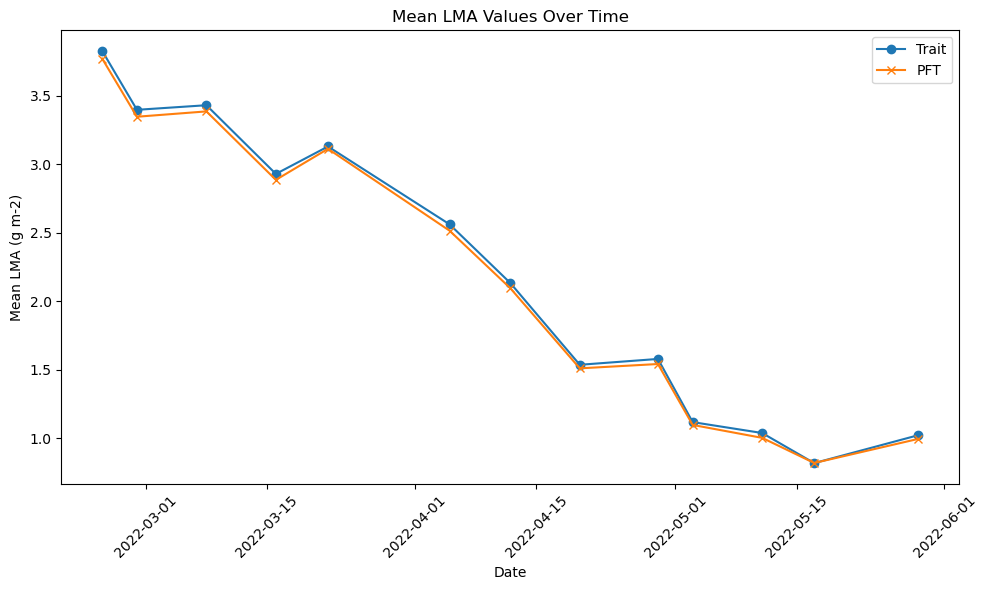

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]


# Base file paths
base_file_path_trait = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"
base_file_path_pft = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/masked_lwc_aviris_dangermond_time_{}.nc"

# Initialize lists to store mean Chl values for each dataset
mean_chl_trait = []
mean_chl_pft = []

# Convert string dates to pandas datetime objects
date_objects = [pd.to_datetime(date) for date in dates]

for i, date in enumerate(date_objects):
    file_trait = base_file_path_trait.format(str(i).zfill(2))
    file_pft = base_file_path_pft.format(str(i).zfill(2))

    # Open datasets
    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)

    # Extract Chl data and calculate mean, ignoring NaN values
    mean_chl_trait.append(ds_trait['lwc'].mean().values)
    mean_chl_pft.append(ds_pft['lwc'].mean().values)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(date_objects, mean_chl_trait, label='Trait', marker='o')
plt.plot(date_objects, mean_chl_pft, label='PFT', marker='x')

# Formatting the plot
plt.xlabel('Date')
plt.ylabel('Mean LMA (g m-2)')
plt.title('Mean LMA Values Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/mean_lwc_over_time.png')
plt.show()


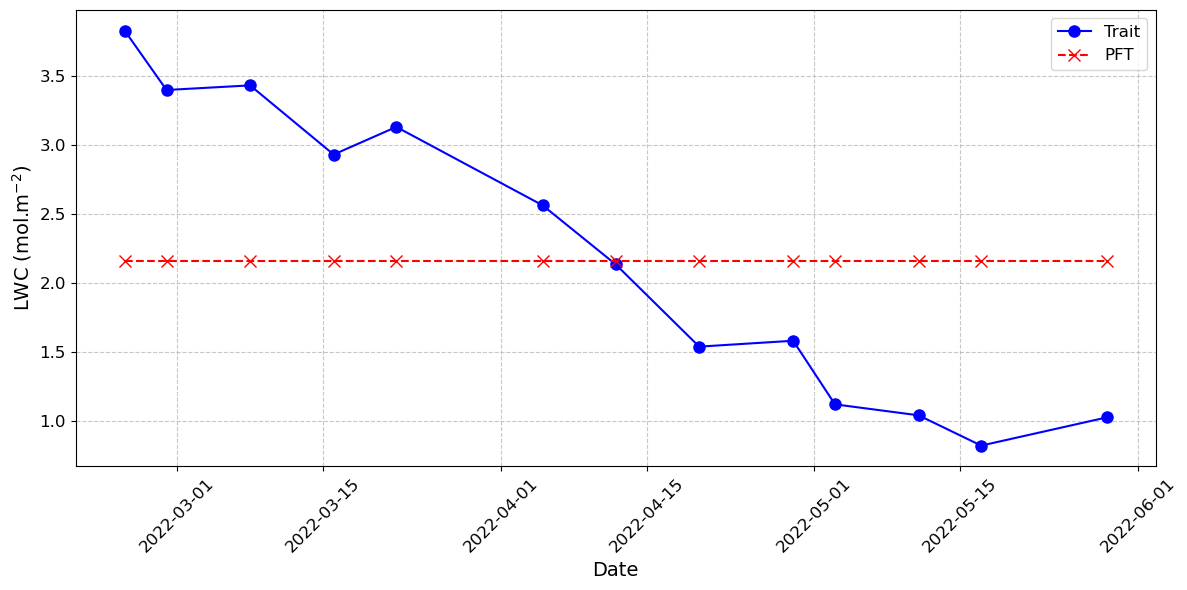

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Given dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Base file paths
base_file_path_trait = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/lwc_aviris_dangermond_clima_fit_time_{}_reg.nc"
base_file_path_pft = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/mean_masked_lwc_aviris_dangermond_clima_fit.nc"

# Initialize lists to store mean Chl values for each dataset
mean_chl_trait = []
mean_chl_pft = []

# Convert string dates to pandas datetime objects
date_objects = [pd.to_datetime(date) for date in dates]

for i, date in enumerate(date_objects):
    file_trait = base_file_path_trait.format(str(i).zfill(2))
    file_pft = base_file_path_pft.format(str(i).zfill(2))

    # Open datasets
    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)

    # Extract Chl data and calculate mean, ignoring NaN values
    mean_chl_trait.append(ds_trait['lwc'].mean().values)
    mean_chl_pft.append(ds_pft['lwc'].mean().values)

# Plotting
plt.figure(figsize=(12, 6))  # Increase figure size for better presentation

# Customize line styles, colors, and markers
plt.plot(date_objects, mean_chl_trait, label='Trait', marker='o', linestyle='-', color='b', markersize=8)
plt.plot(date_objects, mean_chl_pft, label='PFT', marker='x', linestyle='--', color='r', markersize=8)

# Adding gridlines
plt.grid(True, linestyle='--', alpha=0.7)

# Formatting the plot
plt.xlabel('Date', fontsize=14)
plt.ylabel('LWC (mol.m$^{-2}$)', fontsize=14)
#plt.title('Mean Chlorophyll Values Over Time', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/mean_lwc_over_time.png', dpi=300)  # Increase DPI for high-quality output
plt.show()


PFT 2 covers 32.89% of the area
PFT 3 covers 37.95% of the area
PFT 4 covers 29.16% of the area


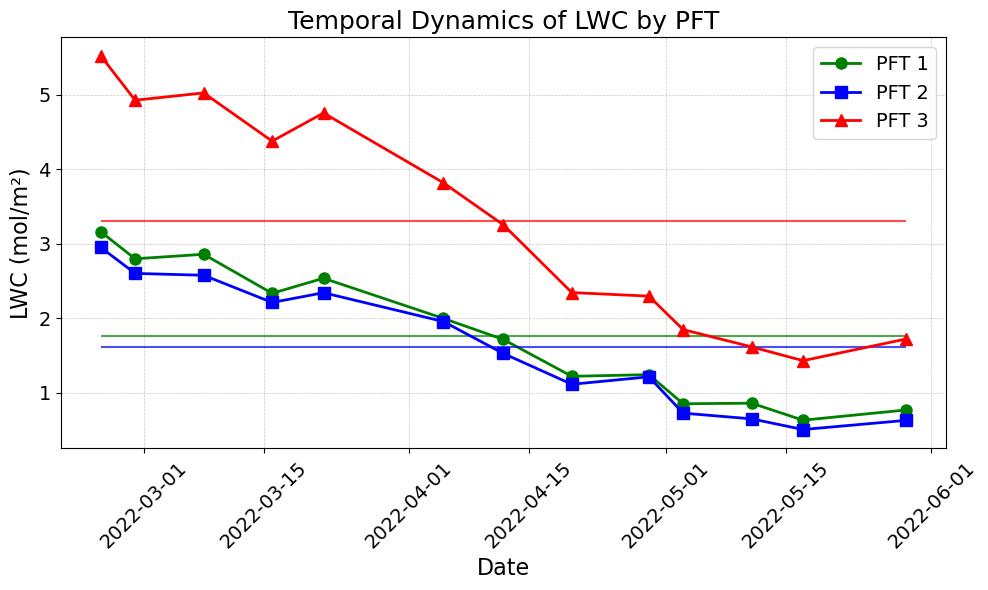

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Given color scheme
colors = ['g', 'b', 'r']  # Original colors for PFTs 2, 3, 4

dates = ["2022-02-24", "2022-02-28", "2022-03-08",
         "2022-03-16", "2022-03-22", "2022-04-05",
         "2022-04-12", "2022-04-20", "2022-04-29",
         "2022-05-03", "2022-05-11", "2022-05-17",
         "2022-05-29"]

pft_categories = [2, 3, 4]
markers = ['o', 's', '^']  # Different markers for each PFT
mean_lwc_pft = {pft: [] for pft in pft_categories}

date_objects = [pd.to_datetime(date) for date in dates]

base_file_path = "/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci/"

pft_ds = xr.open_dataset('../California_Vegetation_WHRTYPE_Dangermond/output_latlon.nc')

# Calculate the percentage coverage for each PFT
pft_counts = np.array([(pft_ds['Band1'].values == pft).sum() for pft in pft_categories])
pft_totals = pft_counts.sum()
pft_percentages = (pft_counts / pft_totals) * 100

# Print the percentages covered by each PFT
for pft, percentage in zip(pft_categories, pft_percentages):
    print(f"PFT {pft} covers {percentage:.2f}% of the area")

for i, date in enumerate(date_objects):
    file_lwc = f'{base_file_path}lwc_aviris_dangermond_clima_fit_time_{str(i).zfill(2)}_reg.nc'
    
    ds_lwc = xr.open_dataset(file_lwc, decode_times=False)
    lwc_values = ds_lwc['lwc'].values.flatten()   # Convert from g.cm^-2 to g.m^-2
    pft_values = pft_ds['Band1'].values.flatten()

    for pft in pft_categories:
        pft_mask = pft_values == pft
        mean_lwc_pft[pft].append(np.nanmean(lwc_values[pft_mask]))

fig, ax = plt.subplots(figsize=(10, 6))  # Adjust the size as needed

# Plotting mean LMA for each PFT with different colors and markers
for pft, color, marker in zip(pft_categories, colors, markers):
    ax.plot(date_objects, mean_lwc_pft[pft], marker=marker, linestyle='-', linewidth=2,
            markersize=8, color=color, label=f'PFT {pft-1}')  # Solid color for PFT

    # Calculate the temporal average for each PFT
    temporal_average = np.nanmean(mean_lwc_pft[pft])
    ax.hlines(temporal_average, date_objects[0], date_objects[-1], colors=color, linestyles='-', alpha=0.7)

ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlabel('Date', fontsize=16)
ax.set_ylabel('LWC (mol/m²)', fontsize=16)
ax.set_title('Temporal Dynamics of LWC by PFT', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis ticks

# Constrained layout for better spacing
plt.tight_layout()
plt.savefig('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/enhanced_mean_lwc_over_time_by_pft_clima_fit.png', dpi=600)  # Use high dpi for publication quality
plt.show()


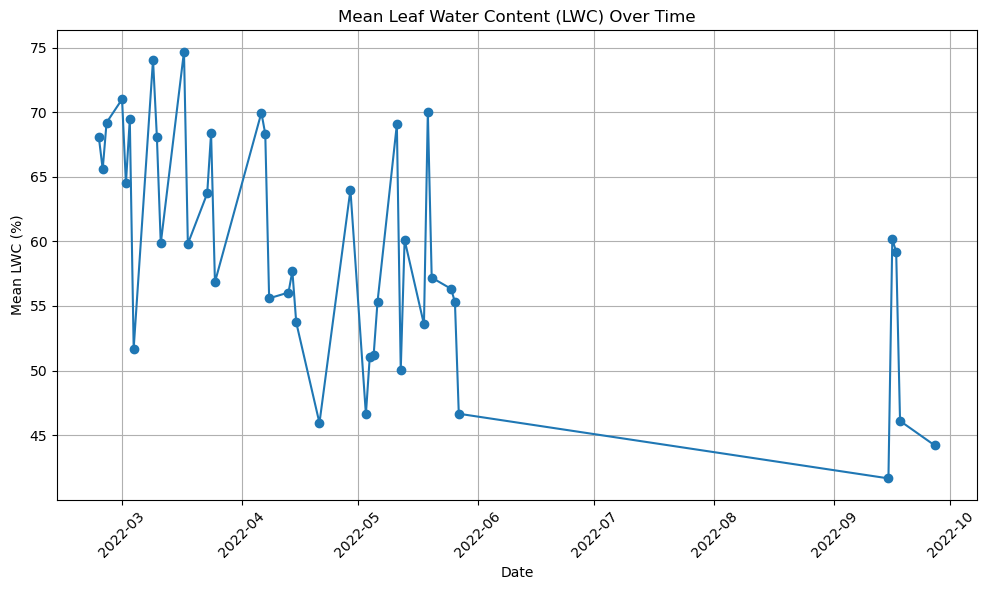

Plot created successfully with mean LMA values.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you've already uploaded the CSV file and it's named 'SHIFT_Leaf_Traits_Chl.csv'
csv_file = '/home/renatob/data/FluoData1/aviris_dangermond/traits/orders/b74733107ab240e64f230e7bb4bfce48/SHIFT_Leaf_Traits_Chl_SB_CA/data/SHIFT_Leaf_Traits_LMA_LWC_Chl.csv'  # Replace with your CSV file path

# Read the CSV file
data = pd.read_csv(csv_file)

# Convert the 'sample_date' column to datetime
data['sample_date'] = pd.to_datetime(data['sample_date'])

# Remove rows with negative LMA values
data = data[data['LWC'] >= 0]

# Group the data by 'sample_date' and calculate the mean of the LMA values for each date
mean_lwc_by_date = data.groupby('sample_date')['LWC'].mean().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(mean_lwc_by_date['sample_date'], mean_lwc_by_date['LWC'], marker='o', linestyle='-')
plt.title('Mean Leaf Water Content (LWC) Over Time')
plt.xlabel('Date')
plt.ylabel('Mean LWC (%)')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate dates for better readability
plt.tight_layout()

# Save or show the plot
#plt.savefig('mean_lwc_time_plot.png')  # Save the plot as a PNG file
plt.show()  # Uncomment to display the plot instead

print("Plot created successfully with mean LMA values.")


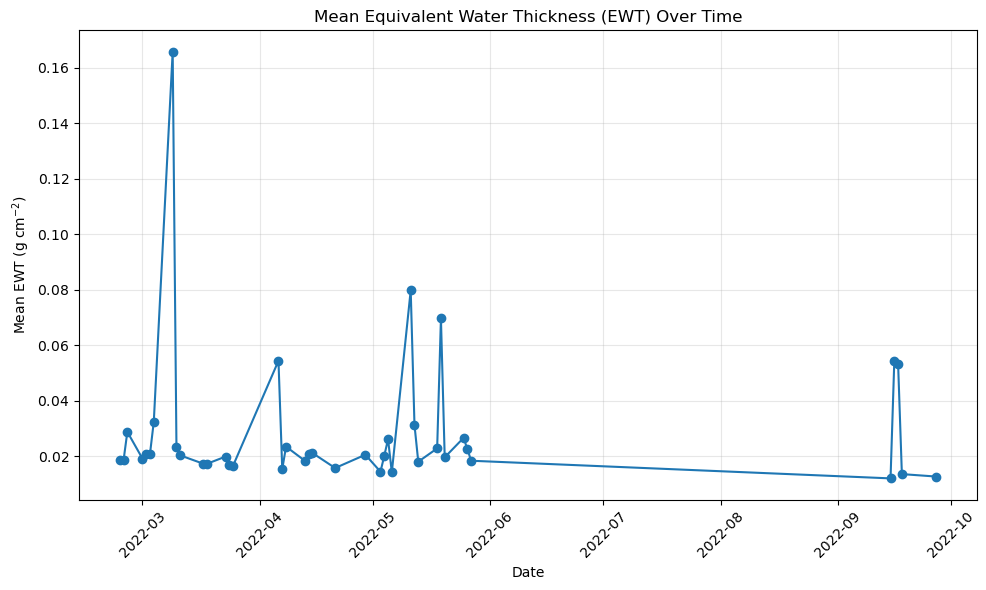

Overall mean EWT: 2.871e-02 g/cm^2 (range 1.21e-02 – 1.66e-01)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- file path ---
csv_file = '/home/renatob/data/FluoData1/aviris_dangermond/traits/orders/b74733107ab240e64f230e7bb4bfce48/SHIFT_Leaf_Traits_Chl_SB_CA/data/SHIFT_Leaf_Traits_LMA_LWC_Chl.csv'

# --- read & clean ---
df = pd.read_csv(csv_file)
df['sample_date'] = pd.to_datetime(df['sample_date'])

# keep valid rows
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['LMA', 'LWC'])
df = df[(df['LMA'] > 0) & (df['LWC'].between(0, 99.9))]

# --- convert LWC% + LMA (g m^-2) -> EWT (g cm^-2) ---
f = df['LWC'] / 100.0                   # fraction of fresh mass that is water
lma_g_cm2 = df['LMA'] / 1e4             # g m^-2 -> g cm^-2
df['EWT_g_cm2'] = lma_g_cm2 * (f / (1.0 - f))   # g/cm^2 (== cm water thickness)

# --- daily mean ---
mean_ewt = df.groupby('sample_date')['EWT_g_cm2'].mean().reset_index()

# --- plot ---
plt.figure(figsize=(10, 6))
plt.plot(mean_ewt['sample_date'], mean_ewt['EWT_g_cm2'], marker='o', linewidth=1.5)
plt.title('Mean Equivalent Water Thickness (EWT) Over Time')
plt.xlabel('Date')
plt.ylabel(r'Mean EWT (g cm$^{-2}$)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# scientific notation on y-axis
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2), useMathText=True)

plt.tight_layout()
plt.show()

print(f"Overall mean EWT: {mean_ewt['EWT_g_cm2'].mean():.3e} g/cm^2 "
      f"(range {mean_ewt['EWT_g_cm2'].min():.2e} – {mean_ewt['EWT_g_cm2'].max():.2e})")


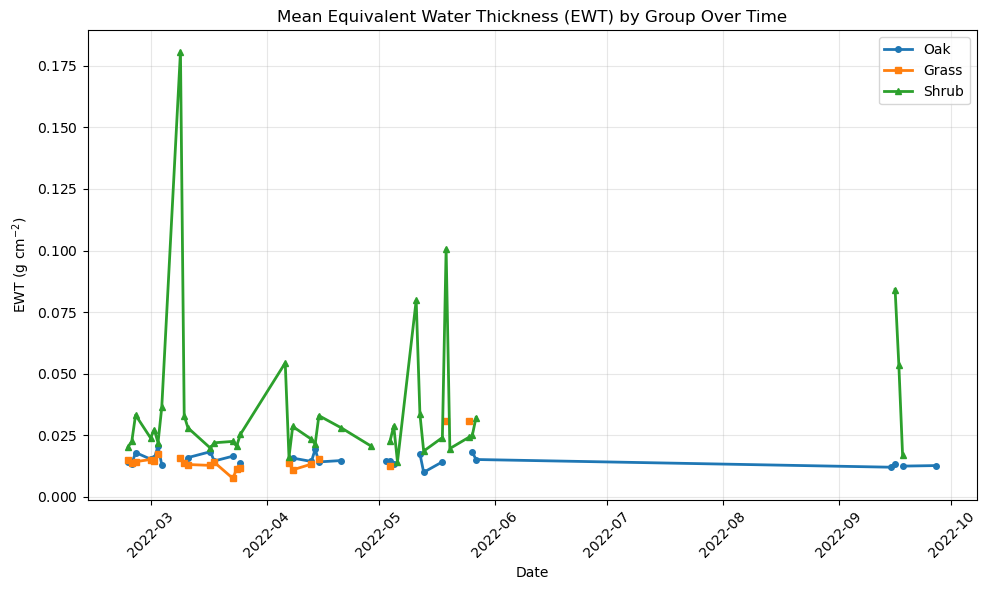

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- file path ---
csv_file = '/home/renatob/data/FluoData1/aviris_dangermond/traits/orders/b74733107ab240e64f230e7bb4bfce48/SHIFT_Leaf_Traits_Chl_SB_CA/data/SHIFT_Leaf_Traits_LMA_LWC_Chl.csv'

# --- load & clean ---
df = pd.read_csv(csv_file)
df['sample_date'] = pd.to_datetime(df['sample_date'])

# force numeric and set sentinel -9999 to NaN
for col in ['LWC', 'LMA']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.replace(-9999, np.nan, inplace=True)

# keep sensible rows
df = df[(df['LWC'].between(0, 100, inclusive='both')) & (df['LMA'] > 0)].copy()

# --- convert to EWT (g·cm^-2) ---
# EWT_g_m2 = LMA * (f / (1 - f)), where f = LWC/100
f = df['LWC'] / 100.0
ewt_g_m2 = df['LMA'] * (f / (1.0 - f))
df['EWT_g_cm2'] = ewt_g_m2 / 1e4  # m^2 -> cm^2

# --- classify to Oak / Grass / Shrub ---
def classify_pft(name: str) -> str:
    s = str(name).lower()

    oak_terms = ['quercus', 'notholithocarpus']  # oaks incl. tanoak
    grass_terms = [
        'annual grass', 'avena', 'bromus', 'stipa', 'elymus',
        'hordeum', 'muhlenbergia', 'elymus', 'elymus', 'elymus',
        'elymus condensatus', 'elymus triticoides', 'elymus glaucus',
        'stipa pulchra', 'elymus glaucus', 'elymus', 'elymus',
        'elymus condensatus', 'hordeum murinum', 'elymus triticoides',
        'elymus', 'distichlis', 'elymus', 'elymus'
    ]
    # treat graminoids as "grasses" for this coarse PFT split
    graminoid_terms = ['carex', 'juncus', 'eleocharis']

    if any(t in s for t in oak_terms):
        return 'Oak'
    if any(t in s for t in grass_terms + graminoid_terms):
        return 'Grass'
    return 'Shrub'  # shrubs + other woody/non-oak taxa

df['Group'] = df['species_or_type'].apply(classify_pft)

# --- aggregate: daily mean EWT by group ---
mean_by_day = (df
               .groupby(['sample_date', 'Group'])['EWT_g_cm2']
               .mean()
               .reset_index())
pivot = mean_by_day.pivot(index='sample_date', columns='Group', values='EWT_g_cm2') \
                   .sort_index()

# --- plot ---
plt.figure(figsize=(10, 6))
for group, style in zip(['Oak', 'Grass', 'Shrub'],
                        ['-o', '-s', '-^']):
    if group in pivot.columns:
        plt.plot(pivot.index, pivot[group], style, label=group, linewidth=2, ms=4)

plt.title('Mean Equivalent Water Thickness (EWT) by Group Over Time')
plt.xlabel('Date')
plt.ylabel('EWT (g cm$^{-2}$)')
plt.grid(True, alpha=0.3)
plt.legend()

# scientific notation on y-axis (values are small)
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encounte


=== Overall ===
N       222.00000
Bias     -0.04085
RMSE      0.11328
dtype: float64

=== By group ===
   group      N     Bias     RMSE
0  Grass   30.0 -0.01012  0.01872
1    Oak   20.0 -0.01201  0.01313
2  Shrub  172.0 -0.04957  0.12838


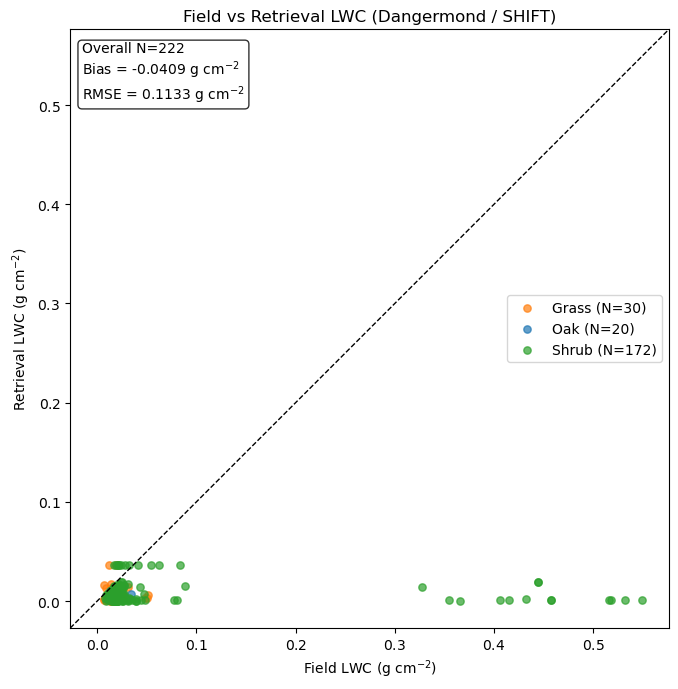

In [12]:
# --- CONFIG ---
FIELD_CSV = "/home/renatob/data/FluoData1/aviris_dangermond/traits/orders/b74733107ab240e64f230e7bb4bfce48/SHIFT_Leaf_Traits_Chl_SB_CA/data/SHIFT_Leaf_Traits_LMA_LWC_Chl.csv"
RETR_DIR  = "/home/renatob/data/FluoData1/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci"
RETR_PATTERN = "lwc_aviris_dangermond_clima_fit_time_{code}_reg.nc"   # file naming pattern
TIME_CODES = [f"{i:02d}" for i in range(0,13)]                        # "00"..."12"

# Optional: if your NetCDFs don't store a usable date, you can map codes -> dates here.
# Example: {"00":"2022-02-23", "01":"2022-03-02", ...}
TIME_TO_DATE = {}  # leave empty to auto-read from file attrs if available

# Sampling / matching
BUFFER_PIXELS = 1        # median over a (2*BUFFER_PIXELS+1)^2 window (use 0 for single pixel)
DATE_WINDOW_DAYS = 3     # ± days for date match (if scene dates are available)

# ----------------
import os, re, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ---------- Helpers ----------
def lwc_molm2_to_ewt_gcm2(lwc_molm2):
    # 1 mol water = 18 g ; 1 m^2 = 10,000 cm^2
    return (lwc_molm2 * 18.0) / 10000.0

def field_to_ewt_gcm2(lwc_percent, lma_g_m2):
    # EWT = (LMA * f)/(1-f) ; LMA in g/m^2 ; convert to g/cm^2 by /10000
    f = np.asarray(lwc_percent, dtype=float) / 100.0
    lma = np.asarray(lma_g_m2, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ewt = (lma * (f / (1.0 - f))) / 10000.0
    return ewt

_GRASS_KEYS = [
    "annual grass","Avena","Bromus","Stipa","Elymus","Hordeum",
    "Muhlenbergia","Poa","Distichlis","Elymus condensatus","Elymus glaucus",
    "Elymus triticoides","Juncus","Carex","Eleocharis","Sisyrinchium","Hesperoyucca"
]

def group_from_species(s):
    s = str(s)
    if "Quercus" in s or "oak" in s.lower():
        return "Oak"
    if any(k.lower() in s.lower() for k in _GRASS_KEYS):
        return "Grass"
    return "Shrub"

def try_parse_scene_date(ds, fallback_code):
    # Try common metadata fields
    cand = None
    for key in ["time", "date", "acquisition_date", "acq_date", "time_coverage_start", "start_time"]:
        if key in ds.attrs:
            cand = ds.attrs.get(key)
            break
    # Also try a coordinate named 'time'
    if cand is None and "time" in ds:
        try:
            v = pd.to_datetime(ds["time"].values)
            if np.ndim(v) == 0:
                return pd.to_datetime(str(v))
            if len(v) > 0:
                return pd.to_datetime(str(v[0]))
        except Exception:
            pass
    if cand is not None:
        try:
            return pd.to_datetime(cand)
        except Exception:
            pass
    # Final fallback: mapping dict
    if fallback_code in TIME_TO_DATE:
        return pd.to_datetime(TIME_TO_DATE[fallback_code])
    return None  # unknown

def find_latlon_vars(ds):
    lat_names = [n for n in ds.coords if n.lower() in ["lat","latitude","y"]]
    lon_names = [n for n in ds.coords if n.lower() in ["lon","longitude","x"]]
    lat = ds[lat_names[0]] if lat_names else None
    lon = ds[lon_names[0]] if lon_names else None
    return lat, lon

def nearest_window_indices(lat_coord, lon_coord, lat0, lon0, buffer_pixels=0):
    # Works with either 1D or 2D lat/lon
    if lat_coord is None or lon_coord is None:
        return None, None, slice(None), slice(None)

    if lat_coord.ndim == 1 and lon_coord.ndim == 1:
        iy = int(np.argmin(np.abs(lat_coord.values - lat0)))
        ix = int(np.argmin(np.abs(lon_coord.values - lon0)))
        ys = slice(max(0, iy-buffer_pixels), min(len(lat_coord), iy+buffer_pixels+1))
        xs = slice(max(0, ix-buffer_pixels), min(len(lon_coord), ix+buffer_pixels+1))
        return iy, ix, ys, xs
    else:
        # 2D lat/lon
        lat2d = lat_coord.values
        lon2d = lon_coord.values
        dist = (lat2d - lat0)**2 + (lon2d - lon0)**2
        iy, ix = np.unravel_index(np.nanargmin(dist), dist.shape)
        ys = slice(max(0, iy-buffer_pixels), min(lat2d.shape[0], iy+buffer_pixels+1))
        xs = slice(max(0, ix-buffer_pixels), min(lat2d.shape[1], ix+buffer_pixels+1))
        return iy, ix, ys, xs

def sample_scene(ds, lat0, lon0, var="lwc", buffer_pixels=0):
    lat, lon = find_latlon_vars(ds)
    if (lat is None) or (lon is None):
        raise ValueError("Could not find lat/lon coordinates in the retrieval dataset.")
    _, _, ys, xs = nearest_window_indices(lat, lon, lat0, lon0, buffer_pixels)
    arr = ds[var].isel({lat.dims[-1]: ys, lon.dims[-1]: xs}) if lat.ndim==1 else ds[var].isel(y=ys, x=xs, drop=False)
    v = np.nanmedian(arr.values)
    return v

# ---------- Load retrieval scenes ----------
scene_rows = []
for code in TIME_CODES:
    f = os.path.join(RETR_DIR, RETR_PATTERN.format(code=code))
    if not os.path.exists(f):
        warnings.warn(f"Missing retrieval file: {f}")
        continue
    ds = xr.open_dataset(f)
    date = try_parse_scene_date(ds, code)
    lat, lon = find_latlon_vars(ds)
    has_latlon = (lat is not None and lon is not None)
    scene_rows.append({"code": code, "file": f, "date": date, "has_latlon": has_latlon})
    ds.close()

scenes_df = pd.DataFrame(scene_rows)
if scenes_df.empty:
    raise RuntimeError("No retrieval scenes found. Check RETR_DIR / pattern / TIME_CODES.")

has_any_dates = scenes_df["date"].notna().any()
if not has_any_dates:
    warnings.warn("No parsable dates found in the retrieval scenes; matching will ignore dates.")

# ---------- Field data -> EWT ----------
field = pd.read_csv(FIELD_CSV)
field["sample_date"] = pd.to_datetime(field["sample_date"], errors="coerce")
# Clean
field = field.replace(-9999, np.nan)
field = field.dropna(subset=["LWC","LMA","latitude","longitude","sample_date"])

# Compute field EWT (g/cm^2)
field["EWT_field"] = field_to_ewt_gcm2(field["LWC"], field["LMA"])
field["group"] = field["species_or_type"].apply(group_from_species)

# ---------- Pair field rows with retrievals ----------
pairs = []
for idx, row in field.iterrows():
    lat0, lon0, d0 = float(row["latitude"]), float(row["longitude"]), row["sample_date"]
    # Select candidate scenes (date window) if dates exist
    cand = scenes_df
    if has_any_dates and pd.notna(d0):
        dmin = d0 - pd.Timedelta(days=DATE_WINDOW_DAYS)
        dmax = d0 + pd.Timedelta(days=DATE_WINDOW_DAYS)
        inwin = cand["date"].between(dmin, dmax, inclusive="both")
        if inwin.any():
            cand = cand.loc[inwin]
        else:
            # fall back: closest by absolute time difference
            if cand["date"].notna().any():
                cand = cand.assign(dt=(cand["date"]-d0).abs()).sort_values("dt").head(1)
    # sample each candidate, take median of available values
    samples = []
    for _, r in cand.iterrows():
        try:
            ds = xr.open_dataset(r["file"])
            v_molm2 = sample_scene(ds, lat0, lon0, var="lwc", buffer_pixels=BUFFER_PIXELS)
            ds.close()
            if np.isfinite(v_molm2):
                samples.append(v_molm2)
        except Exception as e:
            warnings.warn(f"Sampling failed for {r['file']}: {e}")
            continue
    if len(samples)==0:
        retr_gcm2 = np.nan
    else:
        retr_gcm2 = lwc_molm2_to_ewt_gcm2(np.nanmedian(np.array(samples)))

    pairs.append({
        "date": d0.normalize(),
        "lat": lat0, "lon": lon0,
        "species": row["species_or_type"],
        "group": row["group"],
        "EWT_field_gcm2": row["EWT_field"],
        "EWT_retrieval_gcm2": retr_gcm2
    })

pairs = pd.DataFrame(pairs).dropna(subset=["EWT_retrieval_gcm2","EWT_field_gcm2"])

# ---------- Metrics ----------
def metrics(df):
    d = df.dropna(subset=["EWT_field_gcm2","EWT_retrieval_gcm2"])
    if d.empty:
        return pd.Series({"N":0,"Bias":np.nan,"RMSE":np.nan})
    resid = d["EWT_retrieval_gcm2"] - d["EWT_field_gcm2"]
    return pd.Series({
        "N": len(d),
        "Bias": resid.mean(),
        "RMSE": np.sqrt((resid**2).mean())
    })

overall = metrics(pairs)
by_group = pairs.groupby("group").apply(metrics).reset_index()

print("\n=== Overall ===")
print(overall.round(5))
print("\n=== By group ===")
print(by_group.round(5))

# ---------- Scatter plot ----------
colors = {"Oak":"C0","Grass":"C1","Shrub":"C2"}
fig, ax = plt.subplots(figsize=(7,7))
for g, gdf in pairs.groupby("group"):
    ax.scatter(gdf["EWT_field_gcm2"], gdf["EWT_retrieval_gcm2"], s=28, alpha=0.7, label=f"{g} (N={len(gdf)})", color=colors.get(g,"C3"))

# 1:1 line
lims = [
    np.nanmin([pairs["EWT_field_gcm2"].min(), pairs["EWT_retrieval_gcm2"].min()]),
    np.nanmax([pairs["EWT_field_gcm2"].max(), pairs["EWT_retrieval_gcm2"].max()])
]
pad = 0.05*(lims[1]-lims[0])
ax.plot([lims[0]-pad, lims[1]+pad],[lims[0]-pad, lims[1]+pad],"k--",lw=1)

ax.set_xlim(lims[0]-pad, lims[1]+pad)
ax.set_ylim(lims[0]-pad, lims[1]+pad)
ax.set_aspect("equal","box")
ax.set_xlabel("Field LWC (g cm$^{-2}$)")
ax.set_ylabel("Retrieval LWC (g cm$^{-2}$)")
ax.set_title("Field vs Retrieval LWC (Dangermond / SHIFT)")

# Scientific notation ticks (numbers are small)
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.get_major_formatter().set_powerlimits((-2, 2))

# Add metrics box
txt = (
    f"Overall N={int(overall['N'])}\n"
    f"Bias = {overall['Bias']:.4f} g cm$^{{-2}}$\n"
    f"RMSE = {overall['RMSE']:.4f} g cm$^{{-2}}$"
)
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.legend(loc="center right")
plt.tight_layout()
plt.show()


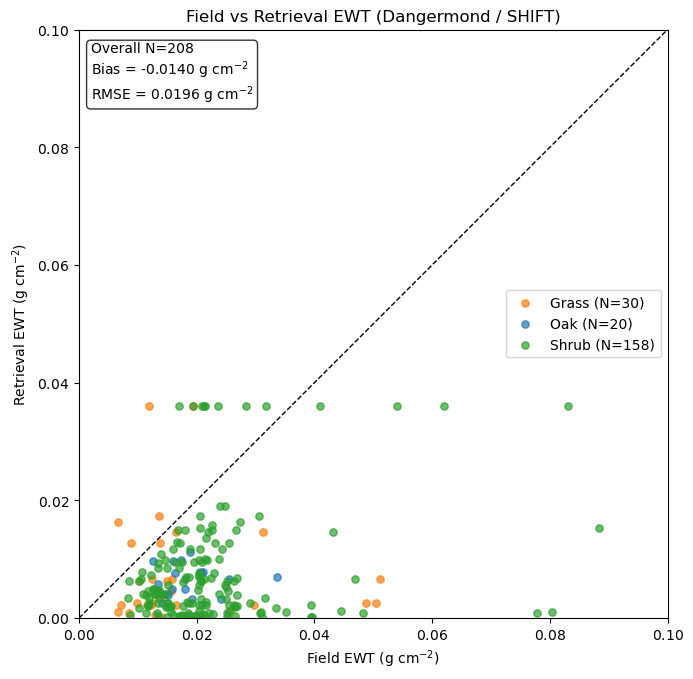

In [14]:
# ----------------
import os, re, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- CONFIG ---
THRESH_EWT = 0.1  # g cm^-2: only plot pairs below this

...
pairs = pd.DataFrame(pairs).dropna(subset=["EWT_retrieval_gcm2","EWT_field_gcm2"])

# ---------- FILTER to < 0.3 g cm^-2 ----------
pairs = pairs[
    (pairs["EWT_field_gcm2"] < THRESH_EWT) &
    (pairs["EWT_retrieval_gcm2"] < THRESH_EWT)
].copy()

# ---------- Metrics ----------
def metrics(df):
    d = df.dropna(subset=["EWT_field_gcm2","EWT_retrieval_gcm2"])
    if d.empty:
        return pd.Series({"N":0,"Bias":np.nan,"RMSE":np.nan})
    resid = d["EWT_retrieval_gcm2"] - d["EWT_field_gcm2"]
    return pd.Series({
        "N": len(d),
        "Bias": resid.mean(),
        "RMSE": np.sqrt((resid**2).mean())
    })
overall = metrics(pairs)
by_group = pairs.groupby("group").apply(metrics).reset_index()

# ---------- Scatter plot ----------
colors = {"Oak":"C0","Grass":"C1","Shrub":"C2"}
fig, ax = plt.subplots(figsize=(7,7))
for g, gdf in pairs.groupby("group"):
    ax.scatter(gdf["EWT_field_gcm2"], gdf["EWT_retrieval_gcm2"],
               s=28, alpha=0.7, label=f"{g} (N={len(gdf)})", color=colors.get(g,"C3"))

# 1:1 line and fixed limits to threshold
ax.plot([0, THRESH_EWT], [0, THRESH_EWT], "k--", lw=1)
ax.set_xlim(0, THRESH_EWT)
ax.set_ylim(0, THRESH_EWT)
ax.set_aspect("equal", "box")

# Labels / title (use EWT wording)
ax.set_xlabel("Field EWT (g cm$^{-2}$)")
ax.set_ylabel("Retrieval EWT (g cm$^{-2}$)")
ax.set_title("Field vs Retrieval EWT (Dangermond / SHIFT)")

# Scientific notation ticks (numbers are small)
from matplotlib.ticker import ScalarFormatter
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.get_major_formatter().set_powerlimits((-2, 2))

# Metrics box
txt = (
    f"Overall N={int(overall['N'])}\n"
    f"Bias = {overall['Bias']:.4f} g cm$^{{-2}}$\n"
    f"RMSE = {overall['RMSE']:.4f} g cm$^{{-2}}$"
)
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.legend(loc="center right")
plt.tight_layout()
plt.show()


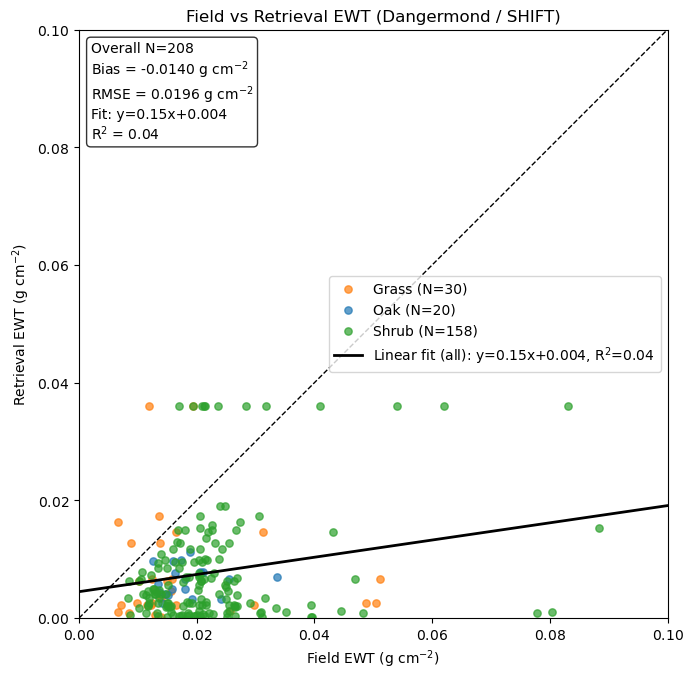

In [15]:
# ---------- Metrics ----------
def metrics(df):
    d = df.dropna(subset=["EWT_field_gcm2","EWT_retrieval_gcm2"])
    if d.empty:
        return pd.Series({"N":0,"Bias":np.nan,"RMSE":np.nan})
    resid = d["EWT_retrieval_gcm2"] - d["EWT_field_gcm2"]
    return pd.Series({
        "N": len(d),
        "Bias": resid.mean(),
        "RMSE": np.sqrt((resid**2).mean())
    })

overall = metrics(pairs)
by_group = pairs.groupby("group").apply(metrics).reset_index()

# ---------- Scatter + linear fits ----------
DO_GROUP_FITS = False  # set True to draw a fit per group as dotted lines

colors = {"Oak":"C0","Grass":"C1","Shrub":"C2"}
fig, ax = plt.subplots(figsize=(7,7))

for g, gdf in pairs.groupby("group"):
    ax.scatter(gdf["EWT_field_gcm2"], gdf["EWT_retrieval_gcm2"],
               s=28, alpha=0.7, label=f"{g} (N={len(gdf)})", color=colors.get(g,"C3"))

# 1:1 line and fixed limits to threshold
ax.plot([0, THRESH_EWT], [0, THRESH_EWT], "k--", lw=1)
ax.set_xlim(0, THRESH_EWT)
ax.set_ylim(0, THRESH_EWT)
ax.set_aspect("equal", "box")

# ----- Overall linear fit (Retrieval = m * Field + b) -----
x = pairs["EWT_field_gcm2"].to_numpy()
y = pairs["EWT_retrieval_gcm2"].to_numpy()
m, b = np.polyfit(x, y, 1)
yhat = m*x + b
r2 = 1.0 - np.sum((y - yhat)**2) / np.sum((y - np.mean(y))**2)

xx = np.linspace(0, THRESH_EWT, 200)
ax.plot(xx, m*xx + b, color="k", lw=2,
        label=f"Linear fit (all): y={m:.2f}x+{b:.3f}, R$^2$={r2:.2f}")

# ----- Optional: per-group fits -----
if DO_GROUP_FITS:
    for g, gdf in pairs.groupby("group"):
        if len(gdf) >= 2:
            mg, bg = np.polyfit(gdf["EWT_field_gcm2"], gdf["EWT_retrieval_gcm2"], 1)
            ax.plot(xx, mg*xx + bg, linestyle=":", lw=1.5, color=colors.get(g,"C3"),
                    label=f"{g} fit: y={mg:.2f}x+{bg:.3f}")

# Labels / title
ax.set_xlabel("Field EWT (g cm$^{-2}$)")
ax.set_ylabel("Retrieval EWT (g cm$^{-2}$)")
ax.set_title("Field vs Retrieval EWT (Dangermond / SHIFT)")

# Scientific notation ticks
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.get_major_formatter().set_powerlimits((-2, 2))

# Metrics box (add fit info)
txt = (
    f"Overall N={int(overall['N'])}\n"
    f"Bias = {overall['Bias']:.4f} g cm$^{{-2}}$\n"
    f"RMSE = {overall['RMSE']:.4f} g cm$^{{-2}}$\n"
    f"Fit: y={m:.2f}x+{b:.3f}\n"
    f"R$^2$ = {r2:.2f}"
)
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.legend(loc="center right")
plt.tight_layout()
plt.show()


In [17]:
from PIL import Image
import os

# Directory containing the PNG images
image_directory = '/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/'

# Output GIF file name
output_gif = 'combined_lwc_map_trait.gif'

# List of PNG files in the directory
png_files = [f for f in os.listdir(image_directory) if f.startswith('lwc_') and f.endswith('_trait_map.png')]
png_files.sort()  # Sort the files in ascending order by filename

# Create a list to store image frames
frames = []

# Open and append each PNG image to the frames list
for png_file in png_files:
    image_path = os.path.join(image_directory, png_file)
    img = Image.open(image_path)
    frames.append(img)

# Save the frames as an animated GIF
frames[0].save(output_gif, save_all=True, append_images=frames[1:], duration=500, loop=0)

print(f'GIF saved as {output_gif}')


FileNotFoundError: [Errno 2] No such file or directory: '/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/'

## Field vs Retrieval: CHL and LMA

Following the same approach as LWC comparison above.

**Unit conversions required:**

- **CHL**: 
  - Field (in situ): mg/m²
  - Retrieval: µg/cm²
  - Conversion: 1 mg/m² = 0.1 µg/cm² → multiply field by 0.1

- **LMA**: 
  - Field (in situ): g/m²
  - Retrieval: g/cm²
  - Conversion: 1 g/cm² = 10,000 g/m² → multiply retrieval by 1e4

Found 508 valid CHL field measurements
Field CHL range (original mg/m²): 0.0 to 907.0
Field CHL range (converted µg/cm²): 0.0 to 90.7


/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encounte


=== CHL Overall ===
N       183.00000
Bias      8.77951
RMSE     28.56309
dtype: float64

=== CHL By group ===
           N     Bias      RMSE
group                          
Grass   30.0  7.48030  26.00724
Oak     17.0  6.39158  28.78776
Shrub  136.0  9.36459  29.06898


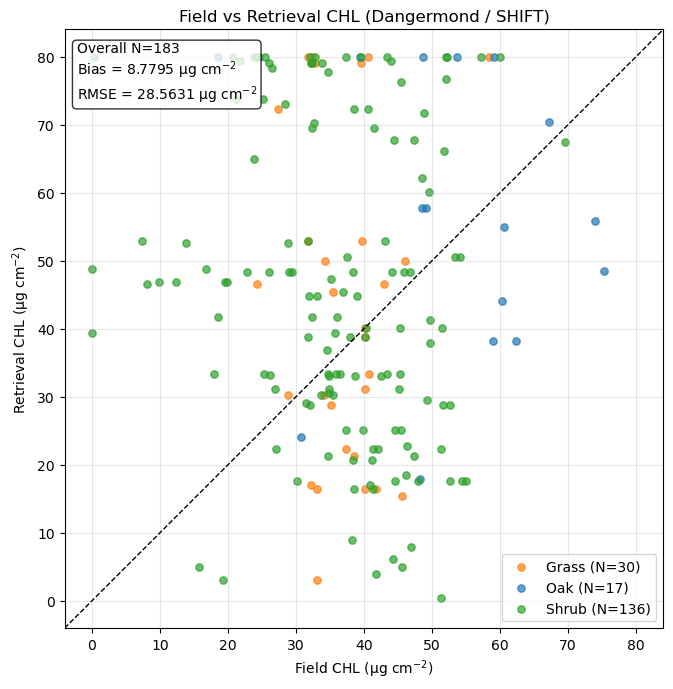

In [24]:
# ---------- CHL Comparison ----------
# UNITS: Field CHL is in mg/m², Retrieval CHL is in µg/cm²
# Conversion: 1 mg/m² = 0.1 µg/cm² 
# We'll convert field to µg/cm² for comparison

RETR_DIR_CHL  = "/home/renatob/data/FluoData1/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci"
RETR_PATTERN_CHL = "chl_aviris_dangermond_clima_fit_time_{code}_reg.nc"

def field_chl_mgm2_to_ugcm2(chl_mgm2):
    """Convert CHL from mg/m² to µg/cm²"""
    # 1 mg/m² = 0.1 µg/cm²
    return chl_mgm2 * 0.1

# ---------- Load retrieval scenes ----------
scene_rows_chl = []
for code in TIME_CODES:
    f = os.path.join(RETR_DIR_CHL, RETR_PATTERN_CHL.format(code=code))
    if not os.path.exists(f):
        warnings.warn(f"Missing CHL retrieval file: {f}")
        continue
    ds = xr.open_dataset(f)
    date = try_parse_scene_date(ds, code)
    lat, lon = find_latlon_vars(ds)
    has_latlon = (lat is not None and lon is not None)
    scene_rows_chl.append({"code": code, "file": f, "date": date, "has_latlon": has_latlon})
    ds.close()

scenes_df_chl = pd.DataFrame(scene_rows_chl)
if scenes_df_chl.empty:
    print("WARNING: No CHL retrieval scenes found.")
else:
    has_any_dates_chl = scenes_df_chl["date"].notna().any()
    
    # Field data
    field_chl = field.copy()
    field_chl = field_chl.dropna(subset=["CHL","latitude","longitude","sample_date"])
    
    if len(field_chl) == 0:
        print("WARNING: No valid CHL field data.")
    else:
        # Convert field CHL from mg/m² to µg/cm² for comparison
        field_chl["CHL_field_ugcm2"] = field_chl_mgm2_to_ugcm2(field_chl["CHL"])
        
        print(f"Found {len(field_chl)} valid CHL field measurements")
        print(f"Field CHL range (original mg/m²): {field_chl['CHL'].min():.1f} to {field_chl['CHL'].max():.1f}")
        print(f"Field CHL range (converted µg/cm²): {field_chl['CHL_field_ugcm2'].min():.1f} to {field_chl['CHL_field_ugcm2'].max():.1f}")
        
        # Pair field rows with retrievals
        pairs_chl = []
        for idx, row in field_chl.iterrows():
            lat0, lon0, d0 = float(row["latitude"]), float(row["longitude"]), row["sample_date"]
            # Select candidate scenes (date window) if dates exist
            cand = scenes_df_chl
            if has_any_dates_chl and pd.notna(d0):
                dmin = d0 - pd.Timedelta(days=DATE_WINDOW_DAYS)
                dmax = d0 + pd.Timedelta(days=DATE_WINDOW_DAYS)
                inwin = cand["date"].between(dmin, dmax, inclusive="both")
                if inwin.any():
                    cand = cand.loc[inwin]
                else:
                    # fall back: closest by absolute time difference
                    if cand["date"].notna().any():
                        cand = cand.assign(dt=(cand["date"]-d0).abs()).sort_values("dt").head(1)
            # sample each candidate, take median of available values
            samples = []
            for _, r in cand.iterrows():
                try:
                    ds = xr.open_dataset(r["file"])
                    v_chl = sample_scene(ds, lat0, lon0, var="chl", buffer_pixels=BUFFER_PIXELS)
                    ds.close()
                    if np.isfinite(v_chl):
                        samples.append(v_chl)
                except Exception as e:
                    warnings.warn(f"CHL sampling failed for {r['file']}: {e}")
                    continue
            if len(samples)==0:
                retr_chl = np.nan
            else:
                retr_chl = np.nanmedian(np.array(samples))
        
            pairs_chl.append({
                "date": d0.normalize(),
                "lat": lat0, "lon": lon0,
                "species": row["species_or_type"],
                "group": row["group"],
                "CHL_field": row["CHL_field_ugcm2"],
                "CHL_retrieval": retr_chl
            })
        
        pairs_chl = pd.DataFrame(pairs_chl).dropna(subset=["CHL_retrieval","CHL_field"])
        
        if len(pairs_chl) == 0:
            print("WARNING: No valid CHL pairs after matching.")
        else:
            # Metrics
            def metrics_chl(df):
                d = df.dropna(subset=["CHL_field","CHL_retrieval"])
                if d.empty:
                    return pd.Series({"N":0,"Bias":np.nan,"RMSE":np.nan})
                resid = d["CHL_retrieval"] - d["CHL_field"]
                return pd.Series({
                    "N": len(d),
                    "Bias": resid.mean(),
                    "RMSE": np.sqrt((resid**2).mean())
                })
            
            overall_chl = metrics_chl(pairs_chl)
            by_group_chl = pairs_chl.groupby("group").apply(metrics_chl)
            
            print("\n=== CHL Overall ===")
            print(overall_chl.round(5))
            print("\n=== CHL By group ===")
            print(by_group_chl.round(5))
            
            # Scatter plot
            colors = {"Oak":"C0","Grass":"C1","Shrub":"C2"}
            fig, ax = plt.subplots(figsize=(7,7))
            for g, gdf in pairs_chl.groupby("group"):
                ax.scatter(gdf["CHL_field"], gdf["CHL_retrieval"], s=28, alpha=0.7, 
                          label=f"{g} (N={len(gdf)})", color=colors.get(g,"C3"))
            
            # 1:1 line
            lims = [
                np.nanmin([pairs_chl["CHL_field"].min(), pairs_chl["CHL_retrieval"].min()]),
                np.nanmax([pairs_chl["CHL_field"].max(), pairs_chl["CHL_retrieval"].max()])
            ]
            pad = 0.05*(lims[1]-lims[0])
            ax.plot([lims[0]-pad, lims[1]+pad],[lims[0]-pad, lims[1]+pad],"k--",lw=1)
            
            ax.set_xlim(lims[0]-pad, lims[1]+pad)
            ax.set_ylim(lims[0]-pad, lims[1]+pad)
            ax.set_aspect("equal","box")
            ax.set_xlabel("Field CHL (µg cm$^{-2}$)")
            ax.set_ylabel("Retrieval CHL (µg cm$^{-2}$)")
            ax.set_title("Field vs Retrieval CHL (Dangermond / SHIFT)")
            
            # Add metrics box
            txt = (
                f"Overall N={int(overall_chl['N'])}\n"
                f"Bias = {overall_chl['Bias']:.4f} µg cm$^{{-2}}$\n"
                f"RMSE = {overall_chl['RMSE']:.4f} µg cm$^{{-2}}$"
            )
            ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
            
            ax.legend(loc="lower right")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

Found 605 valid LMA field measurements
Field LMA range (g/m²): 27.6 to 723.5


/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encountered
  v = np.nanmedian(arr.values)
/tmp/ipykernel_3051102/3594674470.py:111: RuntimeWarning: All-NaN slice encounte


Matched 222 field-retrieval pairs
Retrieval LMA range (converted to g/m²): 7.0 to 498.0

=== LMA Overall ===
N       222.00000
Bias    -35.44450
RMSE    176.08383
dtype: float64

=== LMA By group ===
           N      Bias       RMSE
group                            
Grass   30.0  26.23592  142.09233
Oak     20.0 -59.26759   88.36027
Shrub  172.0 -43.43259  188.65138


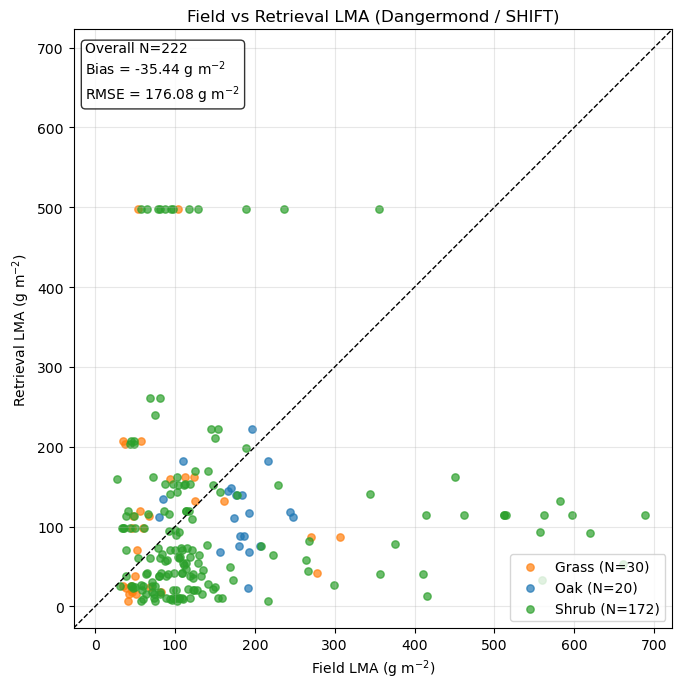

In [28]:
# ---------- LMA Comparison ----------
# UNITS: Field LMA is in g/m², Retrieval LMA is in g/cm²
# Conversion: 1 g/cm² = 10,000 g/m² (multiply retrieval by 1e4)

RETR_DIR_LMA  = "/home/renatob/data/FluoData1/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci"
RETR_PATTERN_LMA = "lma_aviris_dangermond_clima_fit_time_{code}_reg.nc"

def retr_lma_gcm2_to_gm2(lma_gcm2):
    """Convert LMA from g/cm² to g/m²"""
    # 1 m² = 10,000 cm²
    return lma_gcm2 * 1e4

# ---------- Load retrieval scenes ----------
scene_rows_lma = []
for code in TIME_CODES:
    f = os.path.join(RETR_DIR_LMA, RETR_PATTERN_LMA.format(code=code))
    if not os.path.exists(f):
        warnings.warn(f"Missing LMA retrieval file: {f}")
        continue
    ds = xr.open_dataset(f)
    date = try_parse_scene_date(ds, code)
    lat, lon = find_latlon_vars(ds)
    has_latlon = (lat is not None and lon is not None)
    scene_rows_lma.append({"code": code, "file": f, "date": date, "has_latlon": has_latlon})
    ds.close()

scenes_df_lma = pd.DataFrame(scene_rows_lma)
if scenes_df_lma.empty:
    print("WARNING: No LMA retrieval scenes found.")
else:
    has_any_dates_lma = scenes_df_lma["date"].notna().any()
    
    # Field data
    field_lma = field.copy()
    field_lma = field_lma.dropna(subset=["LMA","latitude","longitude","sample_date"])
    
    if len(field_lma) == 0:
        print("WARNING: No valid LMA field data.")
    else:
        print(f"Found {len(field_lma)} valid LMA field measurements")
        print(f"Field LMA range (g/m²): {field_lma['LMA'].min():.1f} to {field_lma['LMA'].max():.1f}")
        
        # Pair field rows with retrievals
        pairs_lma = []
        for idx, row in field_lma.iterrows():
            lat0, lon0, d0 = float(row["latitude"]), float(row["longitude"]), row["sample_date"]
            # Select candidate scenes (date window) if dates exist
            cand = scenes_df_lma
            if has_any_dates_lma and pd.notna(d0):
                dmin = d0 - pd.Timedelta(days=DATE_WINDOW_DAYS)
                dmax = d0 + pd.Timedelta(days=DATE_WINDOW_DAYS)
                inwin = cand["date"].between(dmin, dmax, inclusive="both")
                if inwin.any():
                    cand = cand.loc[inwin]
                else:
                    # fall back: closest by absolute time difference
                    if cand["date"].notna().any():
                        cand = cand.assign(dt=(cand["date"]-d0).abs()).sort_values("dt").head(1)
            # sample each candidate, take median of available values
            samples = []
            for _, r in cand.iterrows():
                try:
                    ds = xr.open_dataset(r["file"])
                    v_lma_gcm2 = sample_scene(ds, lat0, lon0, var="lma", buffer_pixels=BUFFER_PIXELS)
                    ds.close()
                    if np.isfinite(v_lma_gcm2):
                        # Convert from g/cm² to g/m²
                        v_lma_gm2 = retr_lma_gcm2_to_gm2(v_lma_gcm2)
                        samples.append(v_lma_gm2)
                except Exception as e:
                    warnings.warn(f"LMA sampling failed for {r['file']}: {e}")
                    continue
            if len(samples)==0:
                retr_lma = np.nan
            else:
                retr_lma = np.nanmedian(np.array(samples))
        
            pairs_lma.append({
                "date": d0.normalize(),
                "lat": lat0, "lon": lon0,
                "species": row["species_or_type"],
                "group": row["group"],
                "LMA_field": row["LMA"],
                "LMA_retrieval": retr_lma
            })
        
        pairs_lma = pd.DataFrame(pairs_lma).dropna(subset=["LMA_retrieval","LMA_field"])
        
        if len(pairs_lma) == 0:
            print("WARNING: No valid LMA pairs after matching.")
        else:
            print(f"\nMatched {len(pairs_lma)} field-retrieval pairs")
            print(f"Retrieval LMA range (converted to g/m²): {pairs_lma['LMA_retrieval'].min():.1f} to {pairs_lma['LMA_retrieval'].max():.1f}")
            
            # Metrics
            def metrics_lma(df):
                d = df.dropna(subset=["LMA_field","LMA_retrieval"])
                if d.empty:
                    return pd.Series({"N":0,"Bias":np.nan,"RMSE":np.nan})
                resid = d["LMA_retrieval"] - d["LMA_field"]
                return pd.Series({
                    "N": len(d),
                    "Bias": resid.mean(),
                    "RMSE": np.sqrt((resid**2).mean())
                })
            
            overall_lma = metrics_lma(pairs_lma)
            by_group_lma = pairs_lma.groupby("group").apply(metrics_lma)
            
            print("\n=== LMA Overall ===")
            print(overall_lma.round(5))
            print("\n=== LMA By group ===")
            print(by_group_lma.round(5))
            
            # Scatter plot
            colors = {"Oak":"C0","Grass":"C1","Shrub":"C2"}
            fig, ax = plt.subplots(figsize=(7,7))
            for g, gdf in pairs_lma.groupby("group"):
                ax.scatter(gdf["LMA_field"], gdf["LMA_retrieval"], s=28, alpha=0.7, 
                          label=f"{g} (N={len(gdf)})", color=colors.get(g,"C3"))
            
            # 1:1 line
            lims = [
                np.nanmin([pairs_lma["LMA_field"].min(), pairs_lma["LMA_retrieval"].min()]),
                np.nanmax([pairs_lma["LMA_field"].max(), pairs_lma["LMA_retrieval"].max()])
            ]
            pad = 0.05*(lims[1]-lims[0])
            ax.plot([lims[0]-pad, lims[1]+pad],[lims[0]-pad, lims[1]+pad],"k--",lw=1)
            
            ax.set_xlim(lims[0]-pad, lims[1]+pad)
            ax.set_ylim(lims[0]-pad, lims[1]+pad)
            ax.set_aspect("equal","box")
            ax.set_xlabel("Field LMA (g m$^{-2}$)")
            ax.set_ylabel("Retrieval LMA (g m$^{-2}$)")
            ax.set_title("Field vs Retrieval LMA (Dangermond / SHIFT)")
            
            # Add metrics box
            txt = (
                f"Overall N={int(overall_lma['N'])}\n"
                f"Bias = {overall_lma['Bias']:.2f} g m$^{{-2}}$\n"
                f"RMSE = {overall_lma['RMSE']:.2f} g m$^{{-2}}$"
            )
            ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
            
            ax.legend(loc="lower right")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

Field LMA (in situ) - g/m²:
  N = 605
  Range: 27.6 to 723.5
  Mean: 161.9 ± 123.6

Retrieval LMA (original) - g/cm²:
  N = 1324267
  Range: 0.0007 to 0.0498
  Mean: 0.0060 ± 0.0078

Retrieval LMA (converted) - g/m²:
  Range: 7.0 to 498.0
  Mean: 60.4 ± 78.0


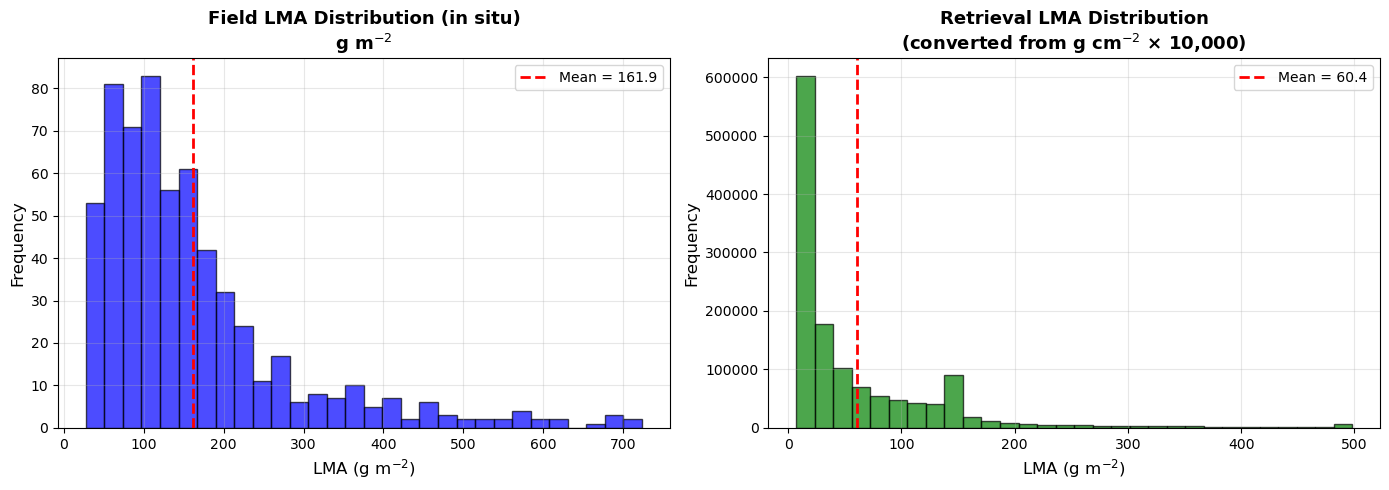


Ratio of means after conversion (field/retrieval): 2.68
(Should be close to 1.0 if units match correctly)


In [30]:
# ---------- LMA Distribution Comparison (Histogram) ----------
# Compare the distributions of field vs retrieval LMA
# Field: g/m², Retrieval: g/cm² (needs conversion by 1e4)

RETR_DIR_LMA  = "/home/renatob/data/FluoData1/aviris_dangermond/traits/datasets/clima_fit_prescribed_lai_ci"
RETR_PATTERN_LMA = "lma_aviris_dangermond_clima_fit_time_{code}_reg.nc"

# Load ALL retrieval LMA values (in g/cm²)
all_retr_lma_gcm2 = []
for code in TIME_CODES:
    f = os.path.join(RETR_DIR_LMA, RETR_PATTERN_LMA.format(code=code))
    if os.path.exists(f):
        ds = xr.open_dataset(f)
        vals = ds['lma'].values.flatten()
        all_retr_lma_gcm2.extend(vals[np.isfinite(vals)])
        ds.close()

all_retr_lma_gcm2 = np.array(all_retr_lma_gcm2)
# Convert to g/m² for comparison
all_retr_lma_gm2 = all_retr_lma_gcm2 * 1e4

# Load ALL field LMA values (in g/m²)
field_lma_vals = field['LMA'].dropna().values

print(f"Field LMA (in situ) - g/m²:")
print(f"  N = {len(field_lma_vals)}")
print(f"  Range: {field_lma_vals.min():.1f} to {field_lma_vals.max():.1f}")
print(f"  Mean: {field_lma_vals.mean():.1f} ± {field_lma_vals.std():.1f}")

print(f"\nRetrieval LMA (original) - g/cm²:")
print(f"  N = {len(all_retr_lma_gcm2)}")
print(f"  Range: {all_retr_lma_gcm2.min():.4f} to {all_retr_lma_gcm2.max():.4f}")
print(f"  Mean: {all_retr_lma_gcm2.mean():.4f} ± {all_retr_lma_gcm2.std():.4f}")

print(f"\nRetrieval LMA (converted) - g/m²:")
print(f"  Range: {all_retr_lma_gm2.min():.1f} to {all_retr_lma_gm2.max():.1f}")
print(f"  Mean: {all_retr_lma_gm2.mean():.1f} ± {all_retr_lma_gm2.std():.1f}")

# Plot histograms - both in g/m² for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Field LMA
ax = axes[0]
ax.hist(field_lma_vals, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('LMA (g m$^{-2}$)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Field LMA Distribution (in situ)\ng m$^{-2}$', fontsize=13, fontweight='bold')
ax.axvline(field_lma_vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {field_lma_vals.mean():.1f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Retrieval LMA (converted to g/m²)
ax = axes[1]
ax.hist(all_retr_lma_gm2, bins=30, alpha=0.7, color='green', edgecolor='black')
ax.set_xlabel('LMA (g m$^{-2}$)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Retrieval LMA Distribution\n(converted from g cm$^{-2}$ × 10,000)', fontsize=13, fontweight='bold')
ax.axvline(all_retr_lma_gm2.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {all_retr_lma_gm2.mean():.1f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify conversion
ratio = field_lma_vals.mean() / all_retr_lma_gm2.mean()
print(f"\nRatio of means after conversion (field/retrieval): {ratio:.2f}")
print(f"(Should be close to 1.0 if units match correctly)")